# Library and Data Imports and Standardization

In [1]:
# Make the imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn as sk

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, GlobalAveragePooling1D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras import regularizers # Import regularizers
from tensorflow.keras.callbacks import EarlyStopping # Import EarlyStopping
import time # Import time
import numpy as np # Import numpy
import pandas as pd # Import pandas
import matplotlib.pyplot as plt # Import matplotlib
import seaborn as sns # Import seaborn
from sklearn.model_selection import train_test_split # Import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report # Import metrics
from tensorflow.keras.preprocessing.sequence import pad_sequences # Import pad_sequences
from tensorflow.keras.datasets import imdb # Import imdb
from pathlib import Path # Import Path

# Import ReduceLRonPlateau
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Import ordinal encoder
from sklearn.preprocessing import OrdinalEncoder

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Import the classification report
from sklearn.metrics import classification_report

# Import the f1 score
from sklearn.metrics import f1_score

# Import train test split
from sklearn.model_selection import train_test_split

# Import KFold
from sklearn.model_selection import KFold

# Import t-SNE and UMAP
from sklearn.manifold import TSNE
import umap.umap_ as umap

# Import pickle
import pickle

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

import random
random.seed(42)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import the datasets

In [2]:
pickle_path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/pickle/'

In [3]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_X_train_combined_imbalanced.pkl', 'rb') as f:
    convabuse_X_train = pickle.load(f)
with open(f'{pickle_path}convabuse_X_test_combined_imbalanced.pkl', 'rb') as f:
    convabuse_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_y_train_combined_imbalanced.pkl', 'rb') as f:
    convabuse_y_train = pickle.load(f)
with open(f'{pickle_path}convabuse_y_test_combined_imbalanced.pkl', 'rb') as f:
    convabuse_y_test = pickle.load(f)

In [4]:
pd.Series(convabuse_y_train).value_counts()

,count
0,8050
3,694
2,599
1,526
4,192


In [5]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_prev_agent_X_train_imbalanced.pkl', 'rb') as f:
    convabuse_prev_agent_X_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_agent_X_test_imbalanced.pkl', 'rb') as f:
    convabuse_prev_agent_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_agent_y_train_imbalanced.pkl', 'rb') as f:
    convabuse_prev_agent_y_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_agent_y_test_imbalanced.pkl', 'rb') as f:
    convabuse_prev_agent_y_test = pickle.load(f)

In [6]:
pd.Series(convabuse_prev_agent_y_train).value_counts()

,count
0,8050
3,694
2,599
1,526
4,192


In [7]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_prev_user_X_train_imbalanced.pkl', 'rb') as f:
    convabuse_prev_user_X_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_user_X_test_imbalanced.pkl', 'rb') as f:
    convabuse_prev_user_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_user_y_train_imbalanced.pkl', 'rb') as f:
    convabuse_prev_user_y_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_user_y_test_imbalanced.pkl', 'rb') as f:
    convabuse_prev_user_y_test = pickle.load(f)

In [8]:
pd.Series(convabuse_prev_user_y_train).value_counts()

,count
0,8050
3,694
2,599
1,526
4,192


In [9]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_agent_X_train_imbalanced.pkl', 'rb') as e:
    convabuse_agent_X_train = pickle.load(e)
with open(f'{pickle_path}convabuse_agent_X_test_imbalanced.pkl', 'rb') as f:
    convabuse_agent_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_agent_y_train_imbalanced.pkl', 'rb') as g:
    convabuse_agent_y_train = pickle.load(g)
with open(f'{pickle_path}convabuse_agent_y_test_imbalanced.pkl', 'rb') as h:
    convabuse_agent_y_test = pickle.load(h)

In [10]:
pd.Series(convabuse_agent_y_train).value_counts()

,count
0,8050
3,694
2,599
1,526
4,192


In [11]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_user_X_train_imbalanced.pkl', 'rb') as e:
    convabuse_user_X_train = pickle.load(e)
with open(f'{pickle_path}convabuse_user_X_test_imbalanced.pkl', 'rb') as f:
    convabuse_user_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_user_y_train_imbalanced.pkl', 'rb') as g:
    convabuse_user_y_train = pickle.load(g)
with open(f'{pickle_path}convabuse_user_y_test_imbalanced.pkl', 'rb') as h:
    convabuse_user_y_test = pickle.load(h)

In [12]:
pd.Series(convabuse_user_y_train).value_counts()

,count
0,8050
3,694
2,599
1,526
4,192


In [13]:
# Open the pickled embeddings
with open(f'{pickle_path}dghs_target_X_train_imbalanced.pkl', 'rb') as e:
    dynamically_generated_hate_speech_target_X_train = pickle.load(e)
with open(f'{pickle_path}dghs_target_X_test_imbalanced.pkl', 'rb') as f:
    dynamically_generated_hate_speech_target_X_test = pickle.load(f)
with open(f'{pickle_path}dghs_target_y_train_imbalanced.pkl', 'rb') as g:
    dynamically_generated_hate_speech_target_y_train = pickle.load(g)
with open(f'{pickle_path}dghs_target_y_test_imbalanced.pkl', 'rb') as h:
    dynamically_generated_hate_speech_target_y_test = pickle.load(h)

In [14]:
pd.Series(dynamically_generated_hate_speech_target_y_train).value_counts()

,count
0,24757
1,7992


In [15]:
# Open the pickled embeddings
with open(f'{pickle_path}dghs_label_X_train_imbalanced.pkl', 'rb') as e:
    dynamically_generated_hate_speech_label_X_train = pickle.load(e)
with open(f'{pickle_path}dghs_label_X_test_imbalanced.pkl', 'rb') as f:
    dynamically_generated_hate_speech_label_X_test = pickle.load(f)
with open(f'{pickle_path}dghs_label_y_train_imbalanced.pkl', 'rb') as g:
    dynamically_generated_hate_speech_label_y_train = pickle.load(g)
with open(f'{pickle_path}dghs_label_y_test_imbalanced.pkl', 'rb') as h:
    dynamically_generated_hate_speech_label_y_test = pickle.load(h)

In [16]:
pd.Series(dynamically_generated_hate_speech_label_y_train).value_counts()

,count
1.0,17574
0.0,15175


In [17]:
# Open the pickled embeddings
with open(f'{pickle_path}mlma_hate_speech_target_X_train_imbalanced.pkl', 'rb') as e:
    mlma_hate_speech_target_X_train = pickle.load(e)
with open(f'{pickle_path}mlma_hate_speech_target_X_test_imbalanced.pkl', 'rb') as f:
    mlma_hate_speech_target_X_test = pickle.load(f)
with open(f'{pickle_path}mlma_hate_speech_target_y_train_imbalanced.pkl', 'rb') as g:
    mlma_hate_speech_target_y_train = pickle.load(g)
with open(f'{pickle_path}mlma_hate_speech_target_y_test_imbalanced.pkl', 'rb') as h:
    mlma_hate_speech_target_y_test = pickle.load(h)

In [18]:
pd.Series(mlma_hate_speech_target_y_train).value_counts()

,count
1,6115
2,1765
0,1024
3,131


## Convabuse Logistic Regression

In [19]:
neural_network_TSNE = {}
neural_network_UMAP = {}

In [20]:
def neural_network_modeling(X_train, X_test, y_train, y_test, dataset):
    results_list = []
    best_model = None
    best_accuracy = -float('inf') # Initialize best accuracy to negative infinity
    best_batch_size = None
    best_learning_rate = None
    best_history = None

    batch_sizes = [8, 16, 32, 64]
    learning_rates = [1e-2, 1e-3, 1e-4]

    print(f"\nNeural Network Modeling - Dataset: {dataset}\n")

    for batch_size in batch_sizes:
        for learning_rate in learning_rates:
            print(f"Training with batch size: {batch_size}, learning rate: {learning_rate}")
            # Define the neural network model with L2 regularization
            model = Sequential([
                Dense(256, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=regularizers.L2(1e-3)),
                Dropout(0.1),
                Dense(128, activation='relu', kernel_regularizer=regularizers.L2(1e-3)),
                Dropout(0.15),
                Dense(64, activation='relu', kernel_regularizer=regularizers.L2(1e-3)),
                Dropout(0.2),
                Dense(len(np.unique(y_train)), activation='softmax')
            ])

            # Compile the model
            model.compile(optimizer=Adam(learning_rate=learning_rate),
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])

            # Define the ReduceLROnPlateau callback
            reduce_lr = ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_delta=1e-5,
                cooldown=0,
                min_lr=1e-8,
                verbose=1,
            )

            # Train the model with the callback and class weights
            start = time.time()
            history = model.fit(X_train, y_train,
                                epochs=200,
                                batch_size=batch_size,
                                validation_split=0.2,
                                verbose=1,
                                callbacks=[reduce_lr, EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)])
            end = time.time()
            training_time = end - start

            # Evaluate on the validation set to find the best model
            val_loss, val_accuracy = model.evaluate(X_train[int(0.8 * len(X_train)):], y_train[int(0.8 * len(y_train)):], verbose=0)

            # Check if the current model has better validation accuracy
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                best_model = model
                best_batch_size = batch_size
                best_learning_rate = learning_rate
                best_history = history
                best_training_time = training_time

    print(f"\nBest model trained with batch size: {best_batch_size} and learning rate: {best_learning_rate}")
    print(f"Training time for best model: {best_training_time:.2f} seconds")


    # Evaluate the best model
    loss, accuracy = best_model.evaluate(X_test, y_test, verbose=0)
    y_pred = np.argmax(best_model.predict(X_test), axis=1)
    f1 = f1_score(y_test, y_pred, average='weighted')
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    print(f"\nDataset: {dataset}, Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate}, Final Test Accuracy: {accuracy}, Final Test F1-score: {f1}, Final Test Macro-F1-score: {macro_f1}")

    # Store results for the best model
    results_list.append((dataset, 'Neural Network', 'Adam', accuracy, f1, macro_f1, 0, best_batch_size, best_learning_rate))

    # Get feature importance (using absolute sum of weights in the first layer as a proxy)
    first_layer_weights = best_model.layers[0].get_weights()[0]
    overall_importance = np.sum(np.abs(first_layer_weights), axis=1)
    best_coefficients_data = dict(zip(range(len(overall_importance)), overall_importance))

    print("Feature Importance (based on first layer weights)")
    print(best_coefficients_data)

    # Plot the predictions that were generated as a histogram using seaborn
    sns.histplot(y_pred, kde=True)
    plt.title(f'Distribution of Predicted Classes for {dataset} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
    plt.show()

    # Explicitly convert y_test to a pandas Series for plotting correlation
    try:
        y_test_series = pd.Series(y_test)
    except Exception as e:
        print(f"Could not convert y_test to pandas Series: {e}")
        y_test_series = None

    # Plot the predictions against a feature (need to select a feature)
    if isinstance(X_test, pd.DataFrame) and y_test_series is not None:
        correlation_series = X_test.corrwith(y_test_series).abs()
        if not correlation_series.empty and not correlation_series.isna().all():
            best_correlated_feature = correlation_series.idxmax()
            sns.scatterplot(x=X_test[best_correlated_feature], y=y_pred, hue=y_test, palette="hot")
            plt.title(f'Predictions vs Best Correlated Feature ({best_correlated_feature}) for {dataset} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
            plt.show()
        else:
            print("Warning: Could not find a feature with sufficient correlation for plotting.")
    elif X_test.shape[1] > 0 and y_test_series is not None:
        sns.scatterplot(x=X_test[:, 0], y=y_pred, hue=y_test, palette="hot")
        plt.title(f'Predictions vs Feature 0 for {dataset} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
        plt.show()
    else:
        print("Warning: X_test is not a pandas DataFrame and has no features for plotting.")


    # Sort the feature importances and plot the top 10 in descending order
    sorted_coefficients = sorted(best_coefficients_data.items(), key=lambda x: x[1], reverse=True)
    top_10_coefficients = sorted_coefficients[:10][::-1]
    top_10_features = [item[0] for item in top_10_coefficients]
    top_10_importances = [item[1] for item in top_10_coefficients]
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_10_features, y=top_10_importances, palette="hot")
    plt.yticks(range(len(top_10_features)), top_10_features)
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    plt.title(f'Top 10 Feature Importances for {dataset} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
    plt.show()

    # Convert the results list into a dataframe
    results = pd.DataFrame(results_list, columns=["Dataset", "Model", "Optimizer", "Accuracy", "F1-score", "Macro F1-score", "Ratio", "Best Batch Size", "Best Learning Rate"])
    results['Importances'] = [best_coefficients_data]
    top_10_coefficients_dict = dict(top_10_coefficients)
    results['Feature Importances'] = [top_10_coefficients_dict]

    # Print a classification report
    print(classification_report(y_test, y_pred))

    # Print a classification matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='hot')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Classification Matrix for {dataset} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
    plt.show()

    # Use t-sne and color code by the target variable
    try:
        import matplotlib.patches as mpatches

        tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
        X_test_tsne = tsne.fit_transform(X_test)

        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=y_test, cmap='hot', alpha=0.6)
        plt.title(f't-SNE Visualization - {dataset} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
        plt.xlabel('t-SNE Component 1')
        plt.ylabel('t-SNE Component 2')

        classes = np.unique(y_test)
        colors = [scatter.cmap(scatter.norm(c)) for c in classes]
        handles = [mpatches.Patch(color=color, label=f'Class {c}') for color, c in zip(colors, classes)]
        plt.legend(handles=handles)

        plt.show()
    except Exception as e:
        print(f"Could not perform t-SNE visualization: {e}")

    # Use t-sne to plot correct vs incorrect predictions
    try:
        correct_predictions = (y_pred == y_test)

        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=correct_predictions, cmap='hot', alpha=0.6)
        plt.title(f't-SNE Visualization of Correct vs Incorrect Predictions - {dataset} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
        plt.xlabel('t-SNE Component 1')
        plt.ylabel('t-SNE Component 2')

        handles = [mpatches.Patch(color=scatter.cmap(scatter.norm(0)), label='Incorrect'),
                   mpatches.Patch(color=scatter.cmap(scatter.norm(1)), label='Correct')]
        plt.legend(handles=handles)

        plt.show()
    except Exception as e:
        print(f"Could not perform t-SNE visualization for correct vs incorrect predictions: {e}")

    # Use UMAP and color code by the target variable
    try:
        import umap.umap_ as umap

        reducer = umap.UMAP(random_state=42)
        X_test_umap = reducer.fit_transform(X_test)

        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(X_test_umap[:, 0], X_test_umap[:, 1], c=y_test, cmap='hot', alpha=0.6)
        plt.title(f'UMAP Visualization - {dataset} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
        plt.xlabel('UMAP Component 1')
        plt.ylabel('UMAP Component 2')

        classes = np.unique(y_test)
        colors = [scatter.cmap(scatter.norm(c)) for c in classes]
        handles = [mpatches.Patch(color=color, label=f'Class {c}') for color, c in zip(colors, classes)]
        plt.legend(handles=handles)

        plt.show()
    except ImportError:
        print("UMAP library not found. Please install it with 'pip install umap-learn'")
    except Exception as e:
        print(f"Could not perform UMAP visualization: {e}")

    neural_network_TSNE[dataset] = X_test_tsne
    neural_network_UMAP[dataset] = X_test_umap

    return results


Neural Network Modeling - Dataset: Convabuse combined

Training with batch size: 8, learning rate: 0.01
Epoch 1/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7975 - loss: 0.8537 - val_accuracy: 0.8082 - val_loss: 0.6423 - learning_rate: 0.0100
Epoch 2/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7930 - loss: 0.7030 - val_accuracy: 0.8082 - val_loss: 0.6572 - learning_rate: 0.0100
Epoch 3/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7968 - loss: 0.6856 - val_accuracy: 0.8082 - val_loss: 0.6418 - learning_rate: 0.0100
Epoch 4/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7908 - loss: 0.7066 - val_accuracy: 0.7923 - val_loss: 0.6398 - learning_rate: 0.0100
Epoch 5/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7965 - loss: 0.6730 - val_accuracy: 0.8082 - val_loss: 0.6219 - learning_rate: 0.0100
Epoch 6/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7943 - loss: 0.6865 - val_accuracy: 0.8082 - val_l

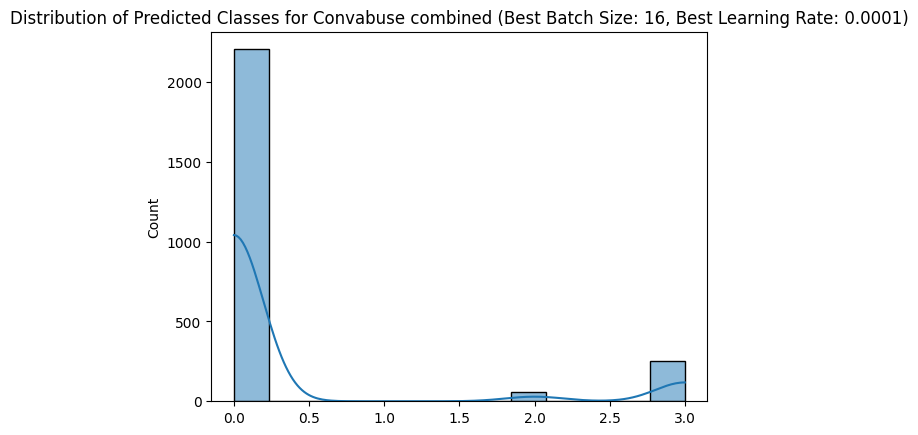

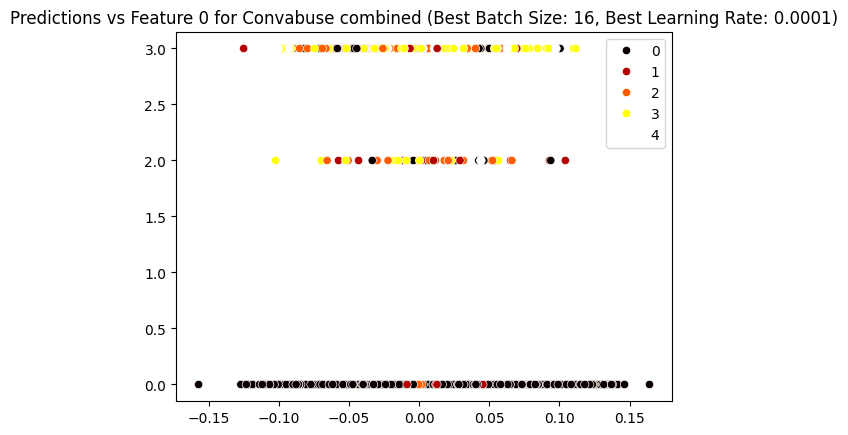

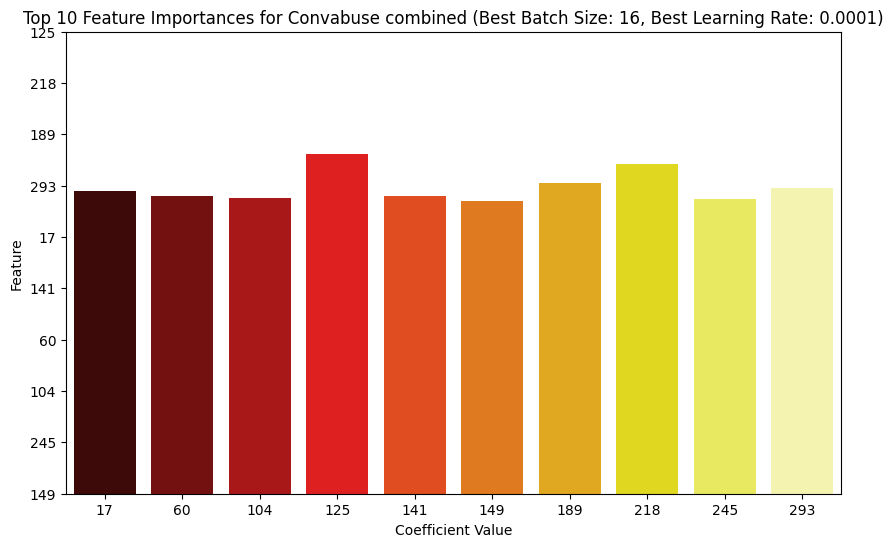

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      2013
           1       0.00      0.00      0.00       132
           2       0.31      0.13      0.18       150
           3       0.47      0.68      0.56       173
           4       0.00      0.00      0.00        48

    accuracy                           0.84      2516
   macro avg       0.34      0.36      0.33      2516
weighted avg       0.77      0.84      0.80      2516



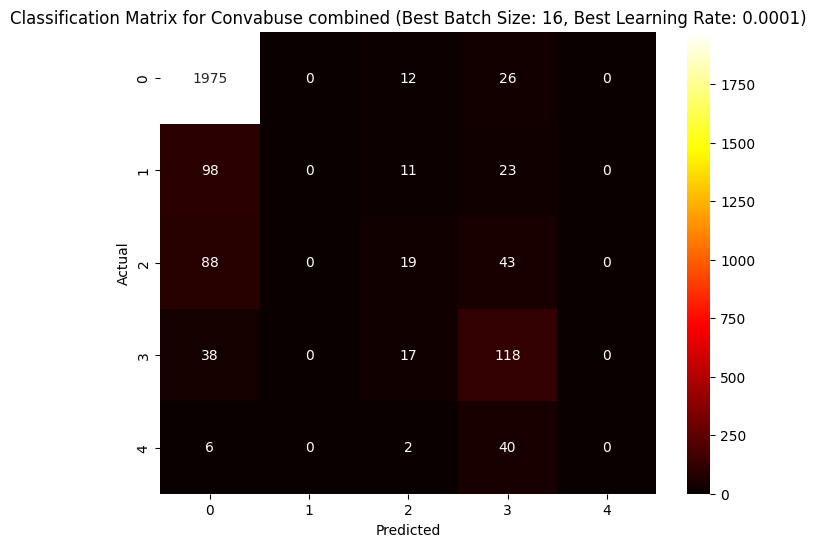

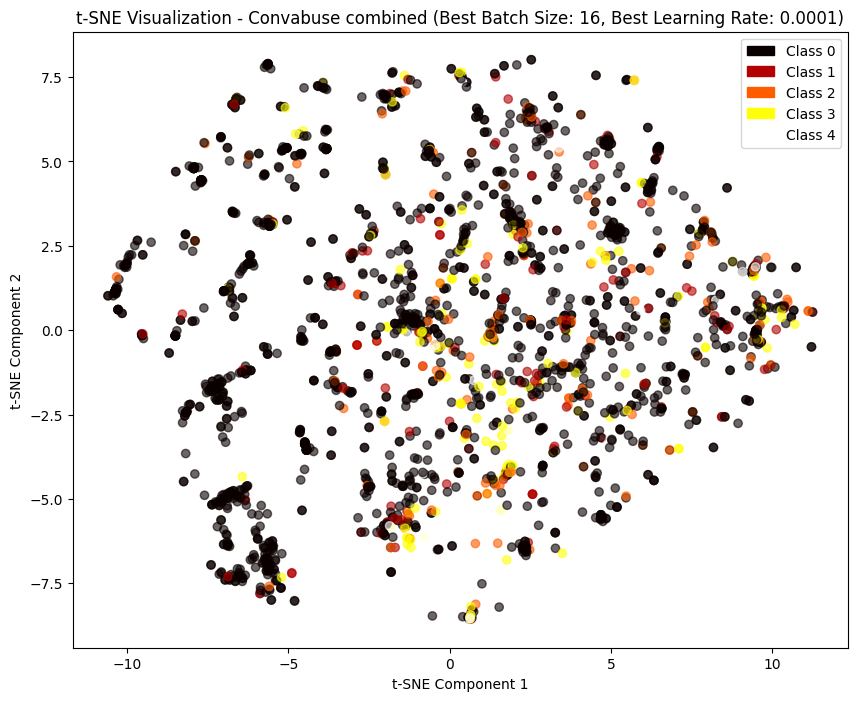

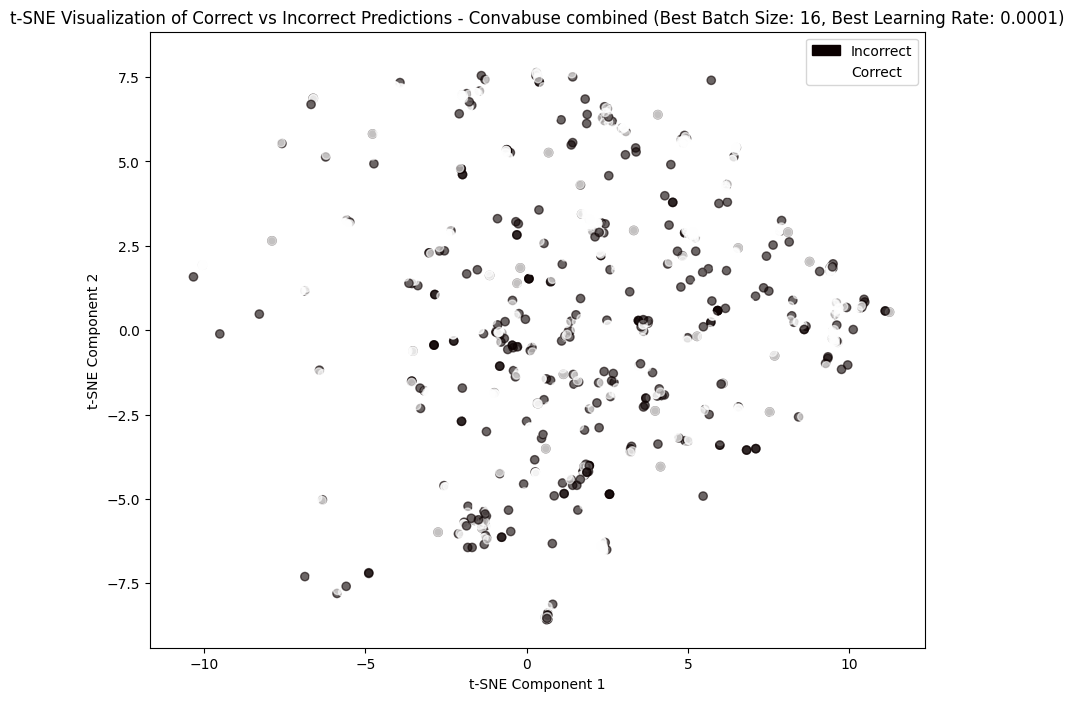

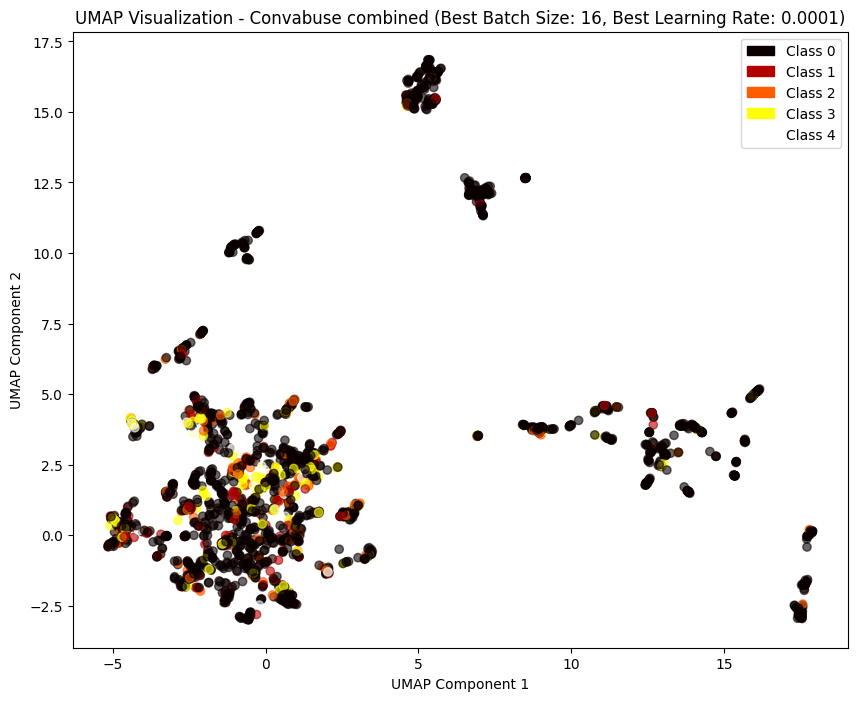

In [21]:
convabuse_combined_results_list = neural_network_modeling(X_train=convabuse_X_train, X_test=convabuse_X_test, y_train=convabuse_y_train, y_test=convabuse_y_test, dataset="Convabuse combined")


Neural Network Modeling - Dataset: Convabuse prev_agent

Training with batch size: 8, learning rate: 0.01
Epoch 1/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7960 - loss: 0.9136 - val_accuracy: 0.8082 - val_loss: 0.7197 - learning_rate: 0.0100
Epoch 2/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7944 - loss: 0.7741 - val_accuracy: 0.8082 - val_loss: 0.7352 - learning_rate: 0.0100
Epoch 3/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7945 - loss: 0.7741 - val_accuracy: 0.8082 - val_loss: 0.7113 - learning_rate: 0.0100
Epoch 4/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7993 - loss: 0.7463 - val_accuracy: 0.8082 - val_loss: 0.7207 - learning_rate: 0.0100
Epoch 5/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7873 - loss: 0.7793 - val_accuracy: 0.8082 - val_loss: 0.7102 - learning_rate: 0.0100
Epoch 6/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7991 - loss: 0.7492 - val_accuracy: 0.8082 - val_

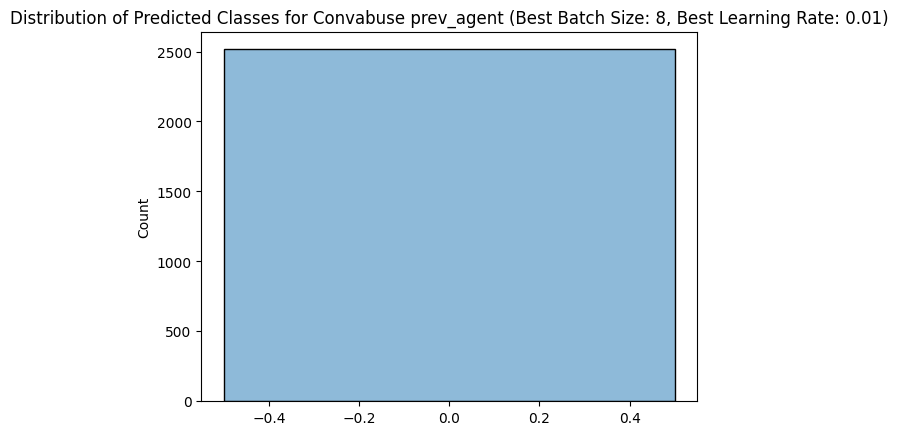

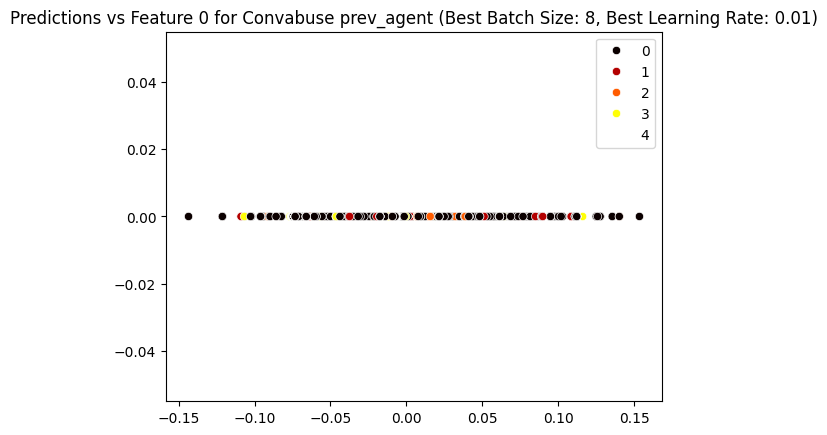

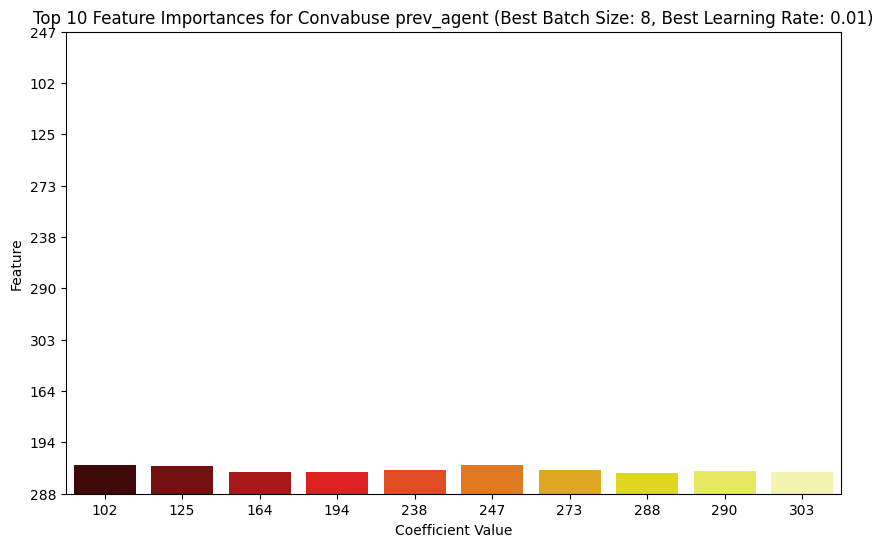

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      2013
           1       0.00      0.00      0.00       132
           2       0.00      0.00      0.00       150
           3       0.00      0.00      0.00       173
           4       0.00      0.00      0.00        48

    accuracy                           0.80      2516
   macro avg       0.16      0.20      0.18      2516
weighted avg       0.64      0.80      0.71      2516



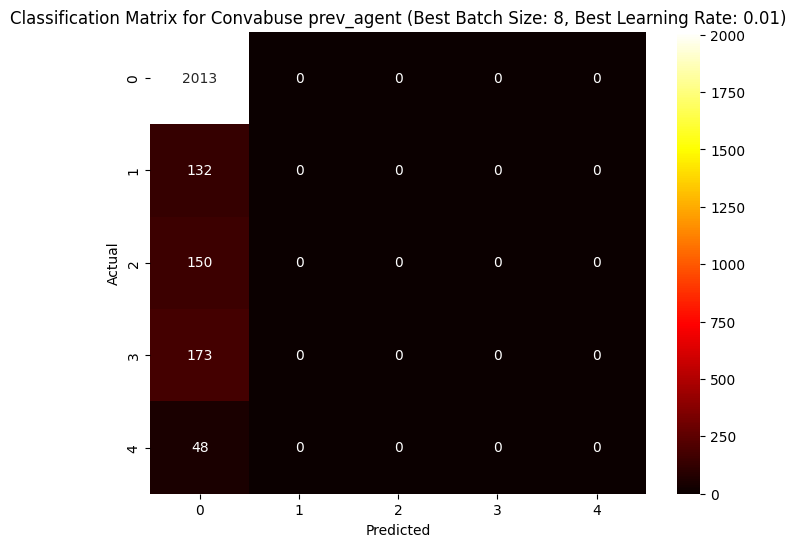

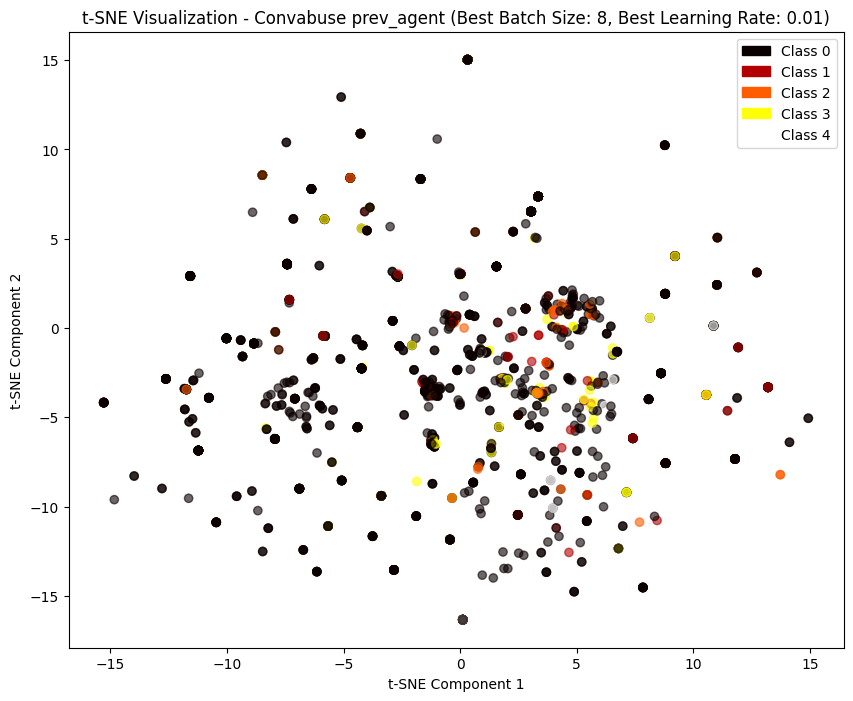

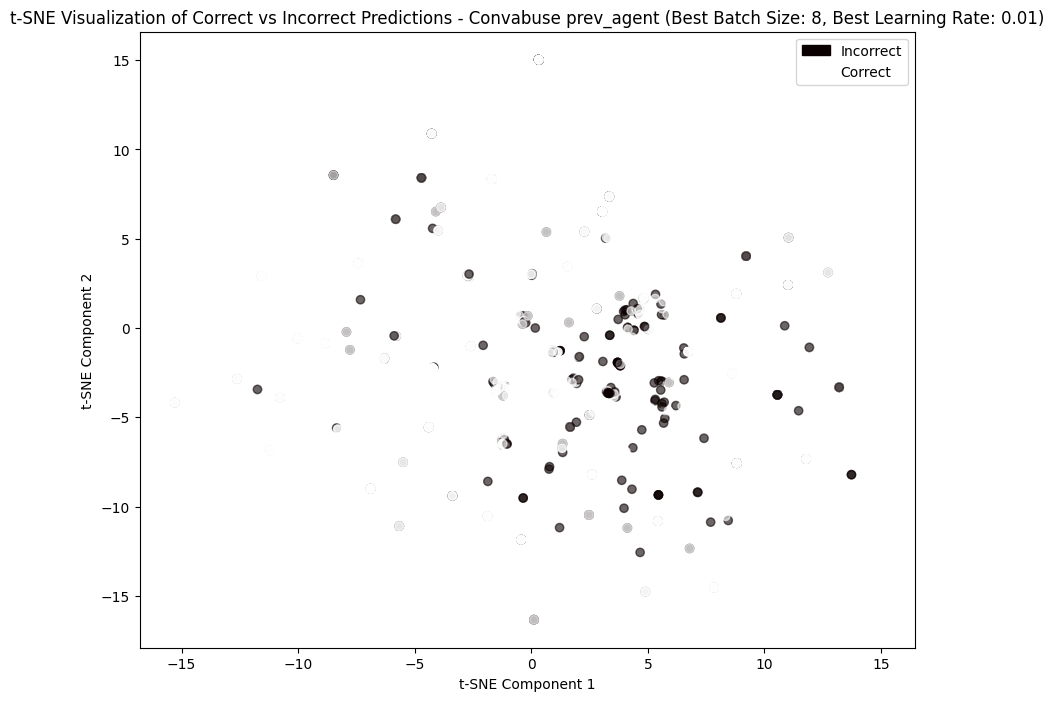

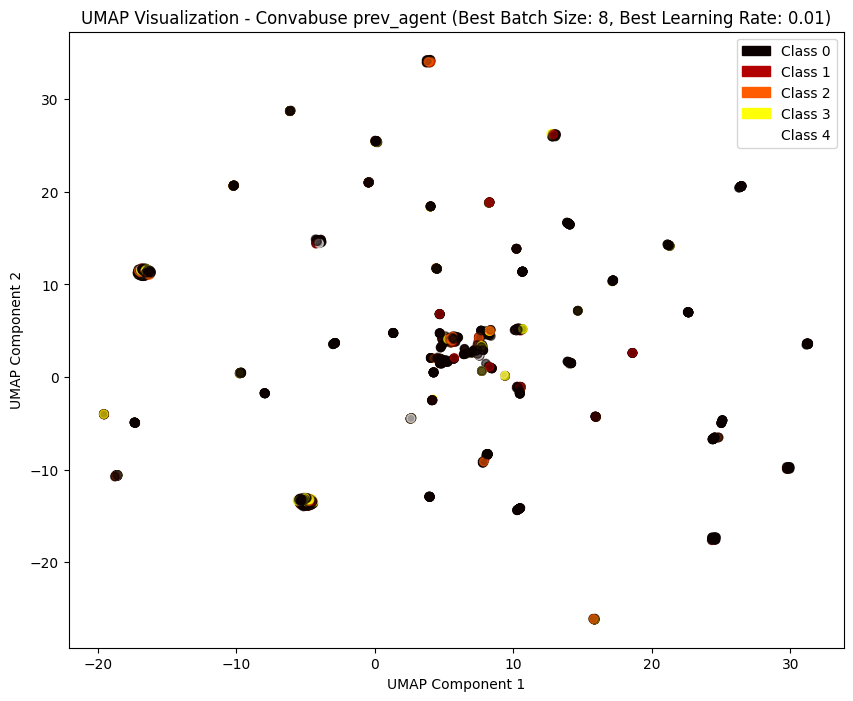

In [22]:
convabuse_prev_agent_results_list = neural_network_modeling(X_train=convabuse_prev_agent_X_train, X_test=convabuse_prev_agent_X_test, y_train=convabuse_prev_agent_y_train, y_test=convabuse_prev_agent_y_test, dataset="Convabuse prev_agent")


Neural Network Modeling - Dataset: Convabuse prev_user

Training with batch size: 8, learning rate: 0.01
Epoch 1/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7964 - loss: 0.9146 - val_accuracy: 0.8082 - val_loss: 0.7227 - learning_rate: 0.0100
Epoch 2/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8038 - loss: 0.7608 - val_accuracy: 0.8082 - val_loss: 0.7466 - learning_rate: 0.0100
Epoch 3/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7910 - loss: 0.7944 - val_accuracy: 0.8082 - val_loss: 0.7261 - learning_rate: 0.0100
Epoch 4/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8019 - loss: 0.7525 - val_accuracy: 0.8082 - val_loss: 0.7556 - learning_rate: 0.0100
Epoch 5/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7960 - loss: 0.7632 - val_accuracy: 0.8082 - val_loss: 0.7196 - learning_rate: 0.0100
Epoch 6/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7986 - loss: 0.7625 - val_accuracy: 0.8082 - val_l

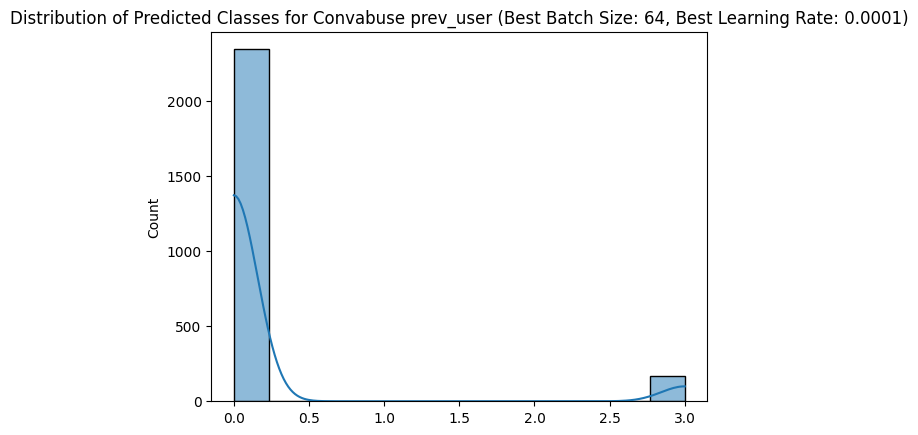

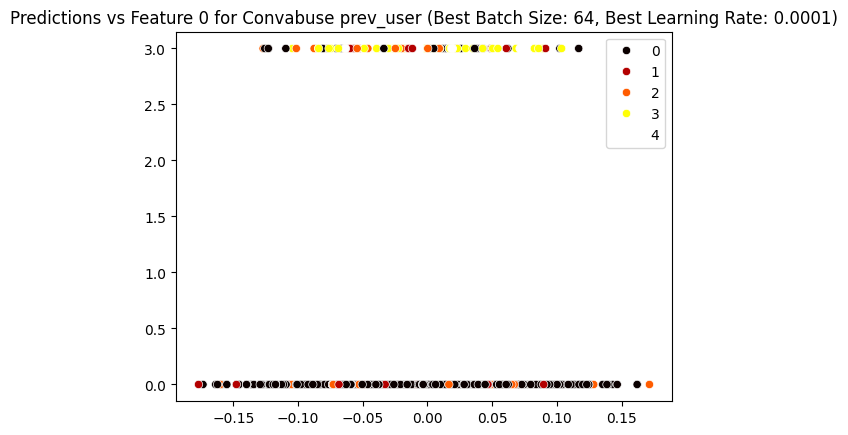

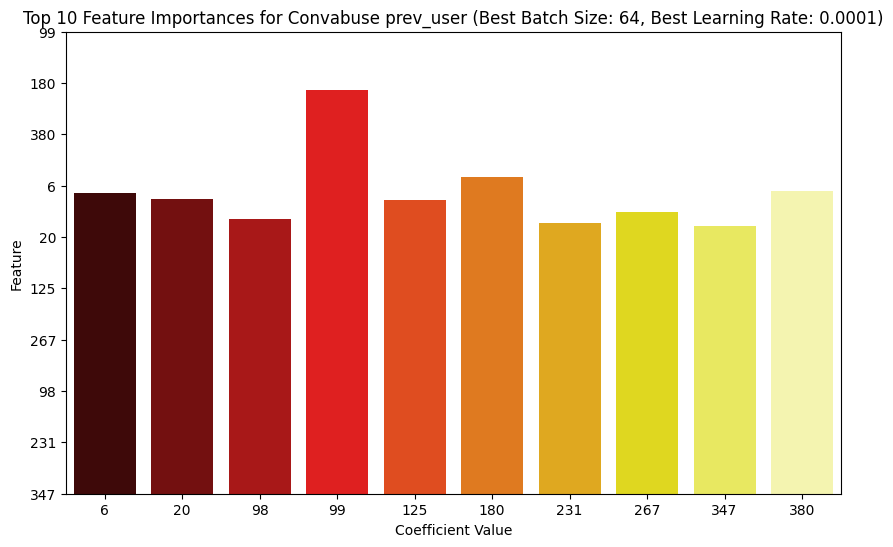

              precision    recall  f1-score   support

           0       0.84      0.98      0.91      2013
           1       0.00      0.00      0.00       132
           2       0.00      0.00      0.00       150
           3       0.42      0.41      0.41       173
           4       0.00      0.00      0.00        48

    accuracy                           0.81      2516
   macro avg       0.25      0.28      0.26      2516
weighted avg       0.70      0.81      0.75      2516



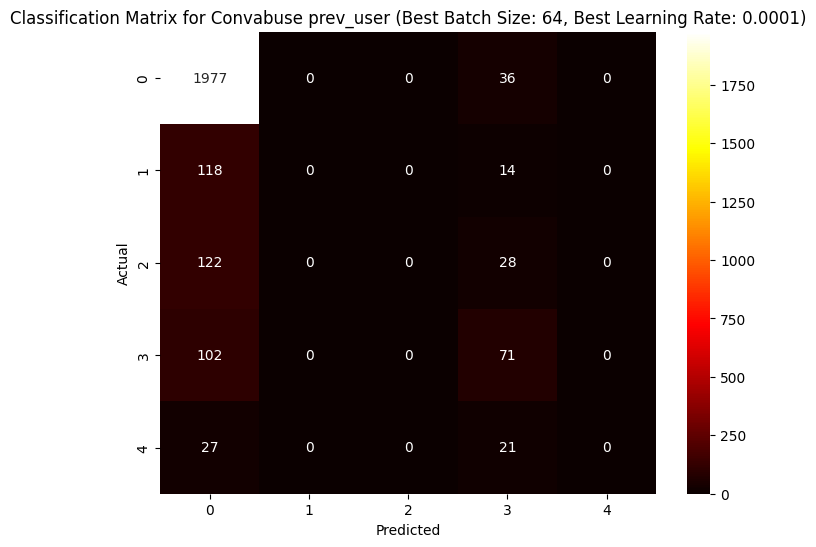

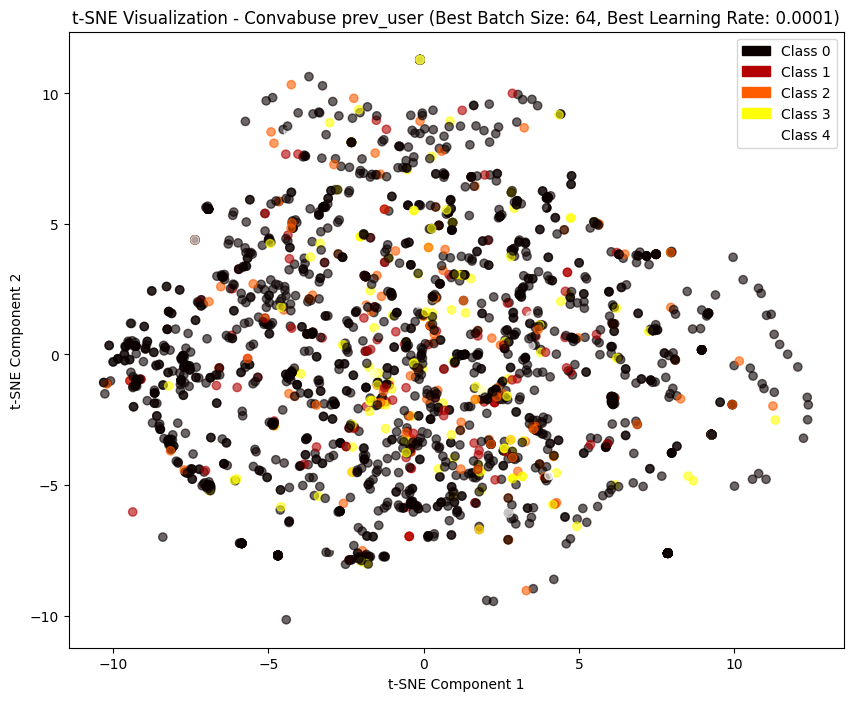

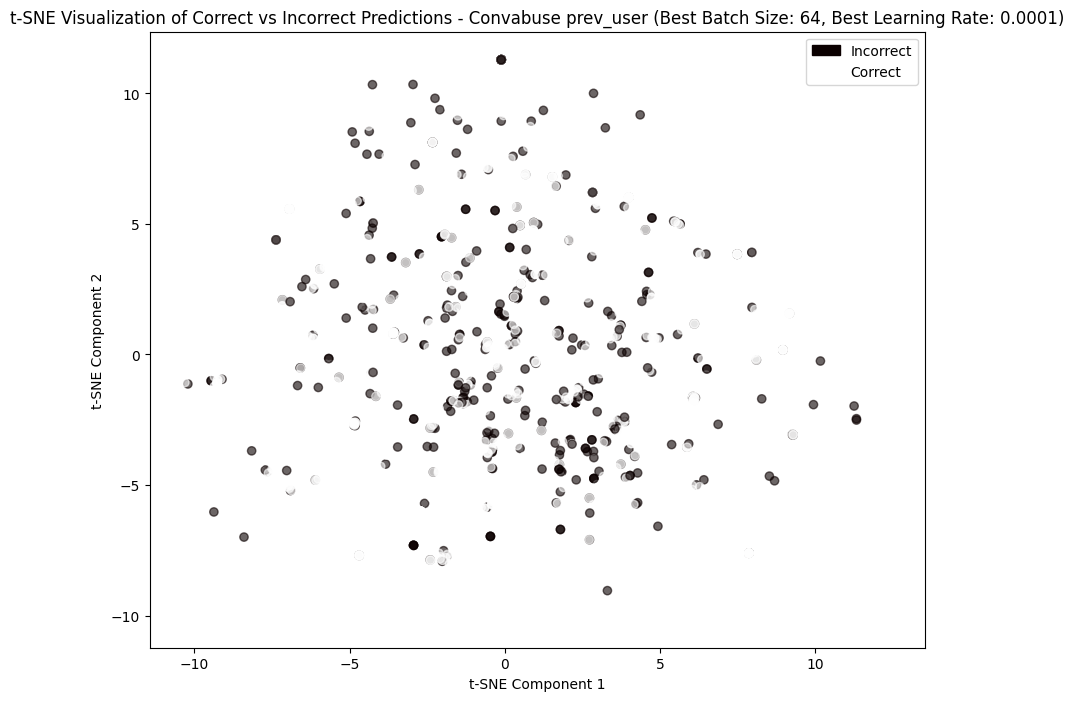

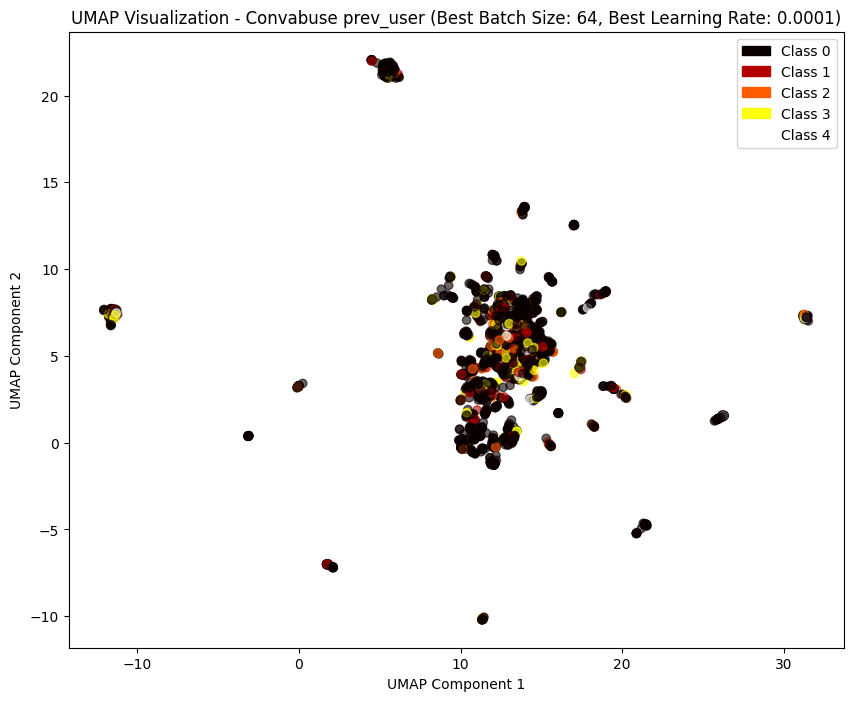

In [23]:
convabuse_prev_user_results_list = neural_network_modeling(convabuse_prev_user_X_train, convabuse_prev_user_X_test, convabuse_prev_user_y_train, convabuse_prev_user_y_test, "Convabuse prev_user")


Neural Network Modeling - Dataset: Convabuse agent

Training with batch size: 8, learning rate: 0.01
Epoch 1/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8083 - loss: 0.8981 - val_accuracy: 0.8082 - val_loss: 0.7509 - learning_rate: 0.0100
Epoch 2/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8044 - loss: 0.7424 - val_accuracy: 0.8082 - val_loss: 0.7222 - learning_rate: 0.0100
Epoch 3/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7963 - loss: 0.7637 - val_accuracy: 0.8082 - val_loss: 0.7052 - learning_rate: 0.0100
Epoch 4/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8018 - loss: 0.7423 - val_accuracy: 0.8082 - val_loss: 0.7174 - learning_rate: 0.0100
Epoch 5/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8029 - loss: 0.7416 - val_accuracy: 0.8082 - val_loss: 0.7094 - learning_rate: 0.0100
Epoch 6/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7985 - loss: 0.7469 - val_accuracy: 0.8082 - val_loss:

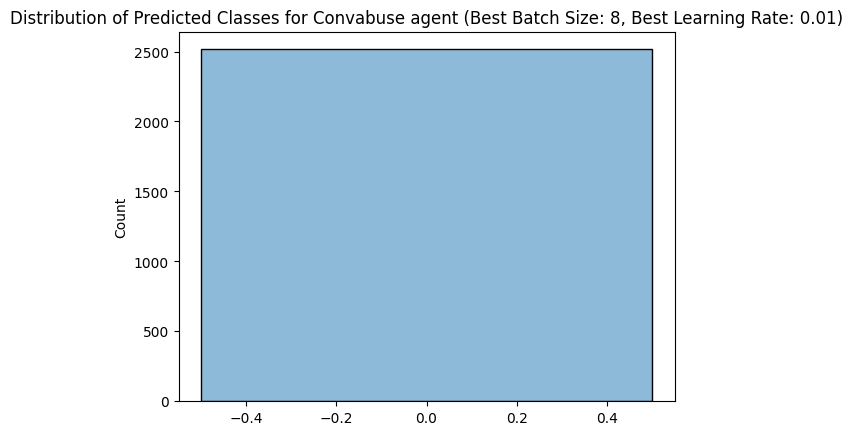

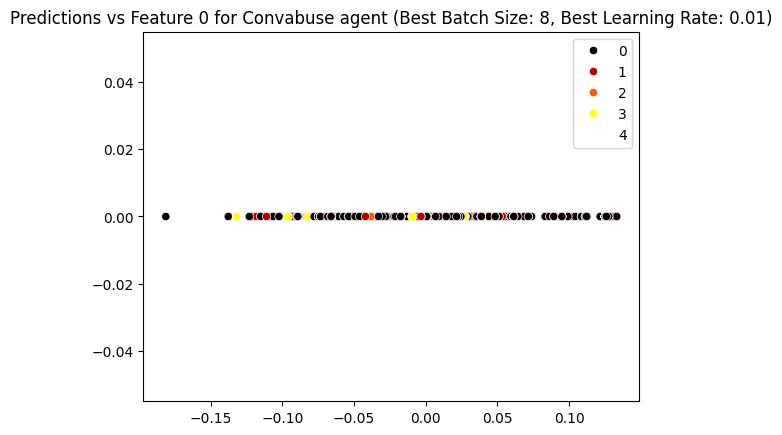

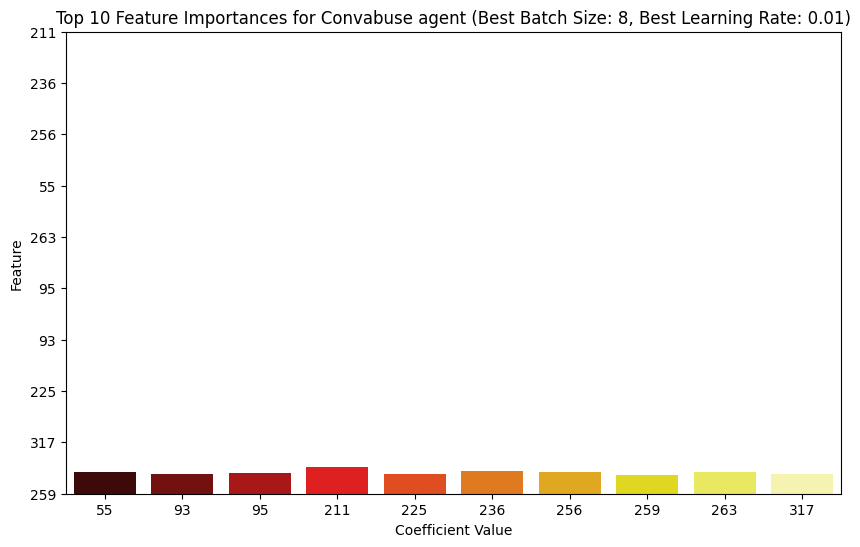

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      2013
           1       0.00      0.00      0.00       132
           2       0.00      0.00      0.00       150
           3       0.00      0.00      0.00       173
           4       0.00      0.00      0.00        48

    accuracy                           0.80      2516
   macro avg       0.16      0.20      0.18      2516
weighted avg       0.64      0.80      0.71      2516



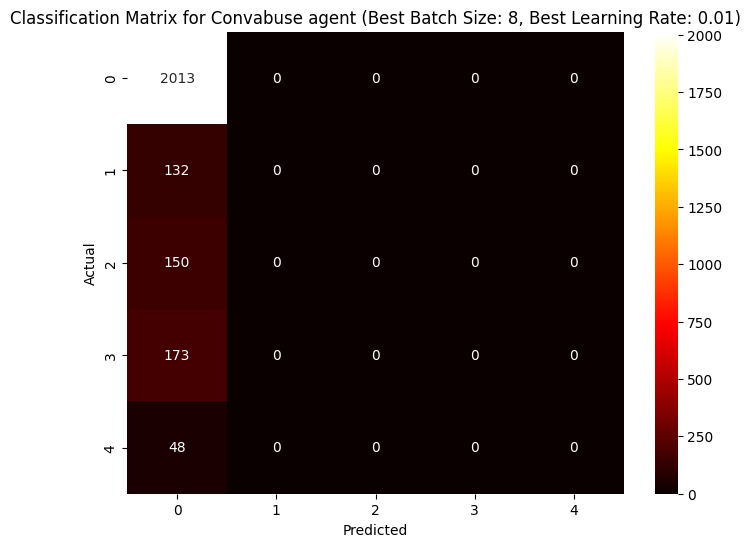

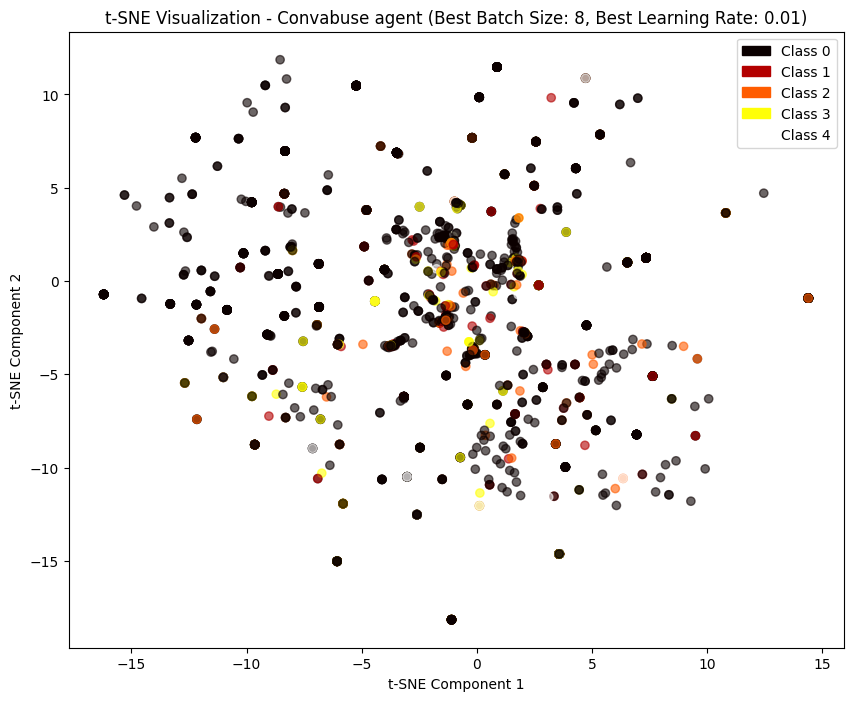

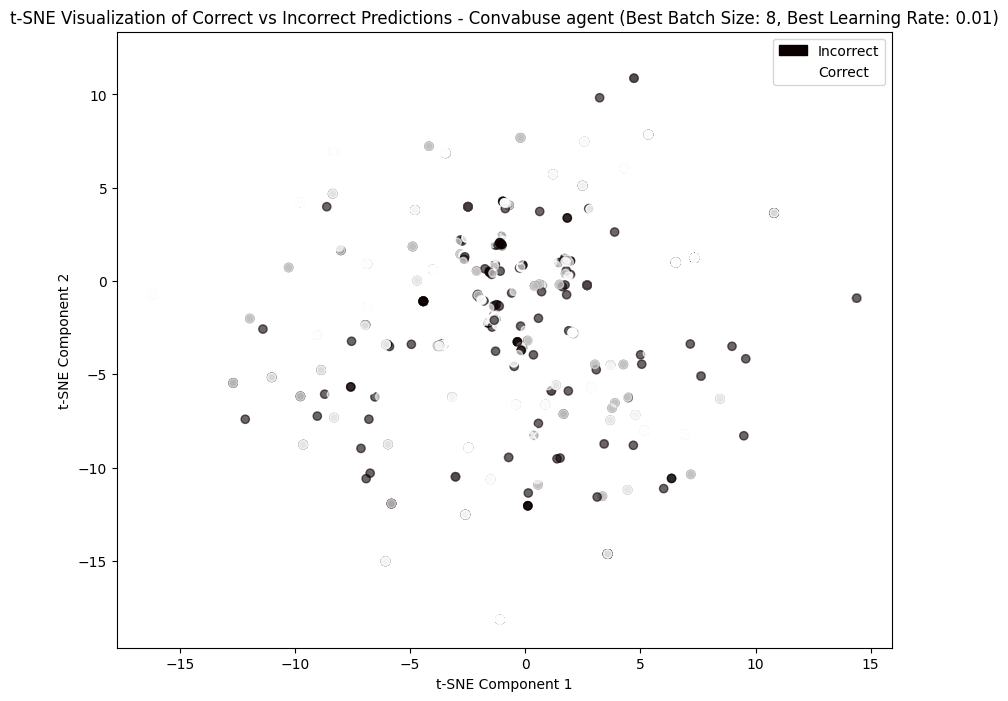

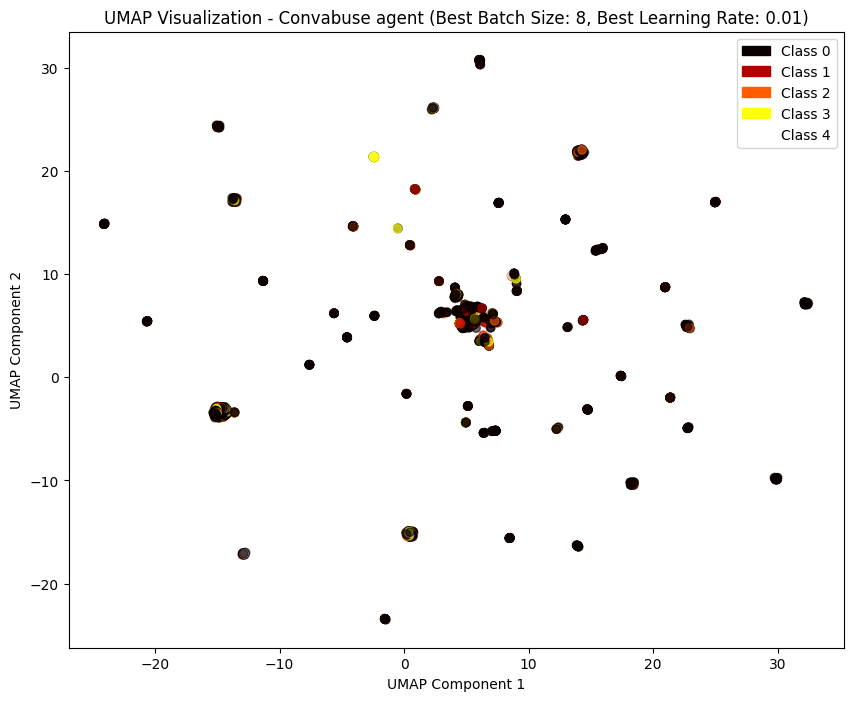

In [24]:
convabuse_agent_results_list = neural_network_modeling(convabuse_agent_X_train, convabuse_agent_X_test, convabuse_agent_y_train, convabuse_agent_y_test, "Convabuse agent")


Neural Network Modeling - Dataset: Convabuse user

Training with batch size: 8, learning rate: 0.01
Epoch 1/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8206 - loss: 0.7963 - val_accuracy: 0.8495 - val_loss: 0.6001 - learning_rate: 0.0100
Epoch 2/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8345 - loss: 0.6238 - val_accuracy: 0.8515 - val_loss: 0.5340 - learning_rate: 0.0100
Epoch 3/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8336 - loss: 0.6076 - val_accuracy: 0.8535 - val_loss: 0.5314 - learning_rate: 0.0100
Epoch 4/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8371 - loss: 0.6095 - val_accuracy: 0.8346 - val_loss: 0.5596 - learning_rate: 0.0100
Epoch 5/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8355 - loss: 0.6115 - val_accuracy: 0.8395 - val_loss: 0.5814 - learning_rate: 0.0100
Epoch 6/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8333 - loss: 0.6037 - val_accuracy: 0.8554 - val_loss: 

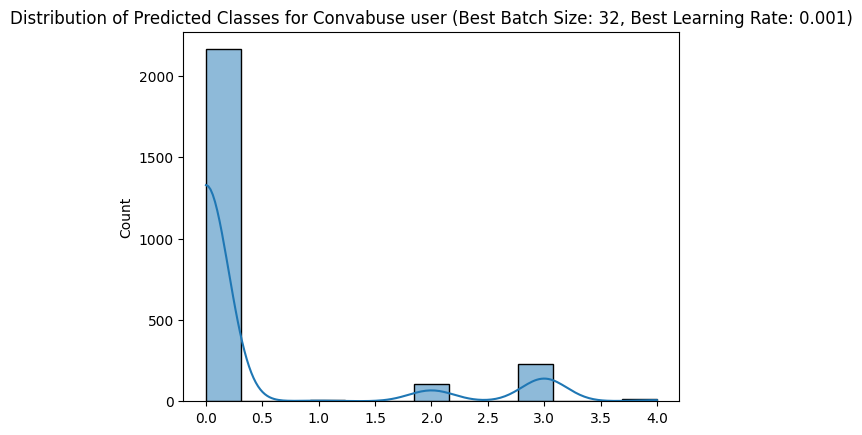

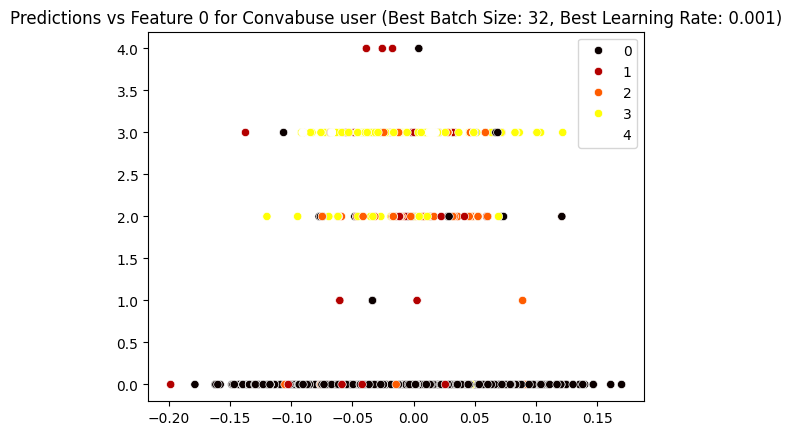

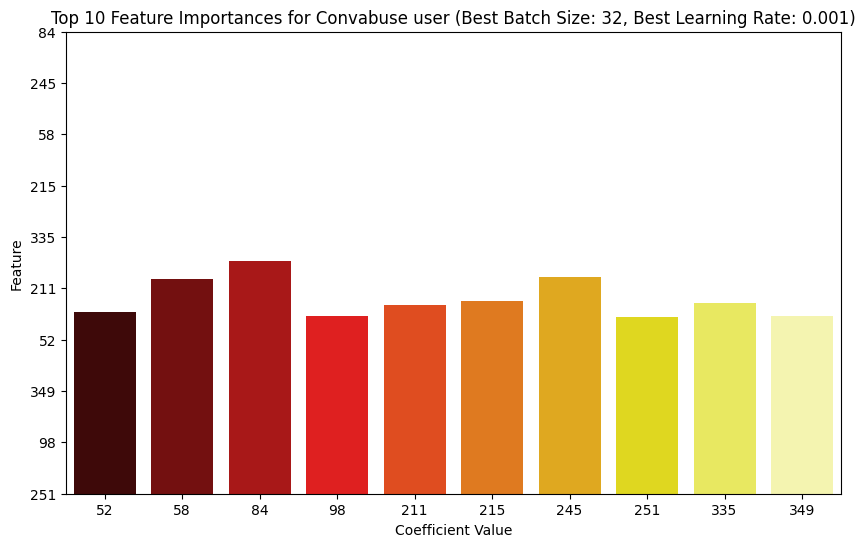

              precision    recall  f1-score   support

           0       0.91      0.98      0.95      2013
           1       0.33      0.02      0.03       132
           2       0.40      0.29      0.34       150
           3       0.57      0.75      0.65       173
           4       0.64      0.15      0.24        48

    accuracy                           0.86      2516
   macro avg       0.57      0.44      0.44      2516
weighted avg       0.82      0.86      0.83      2516



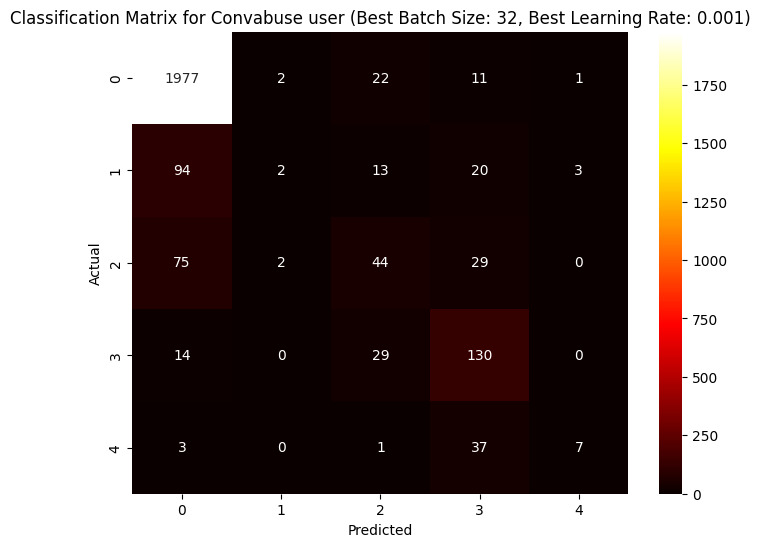

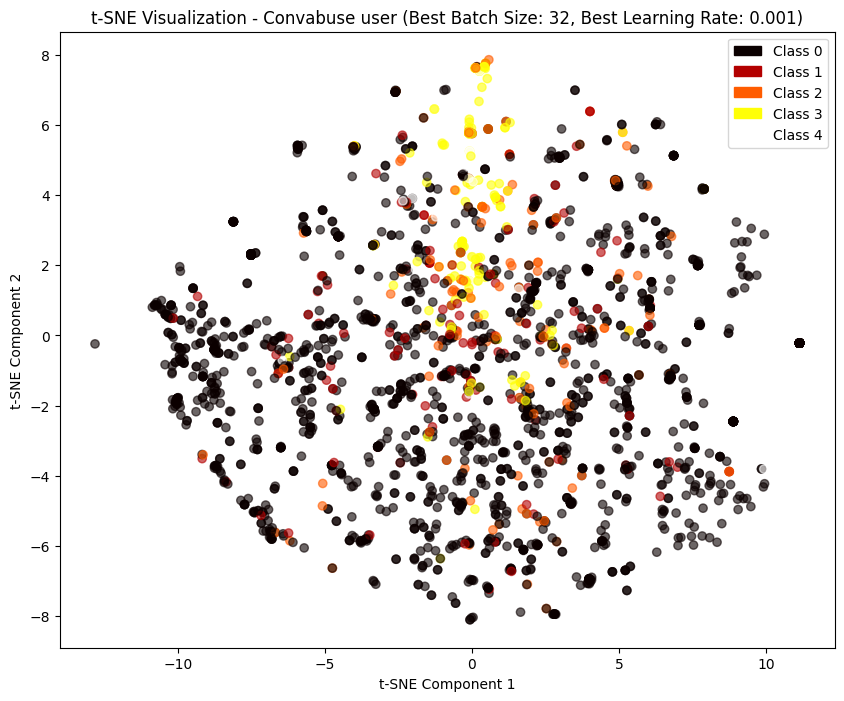

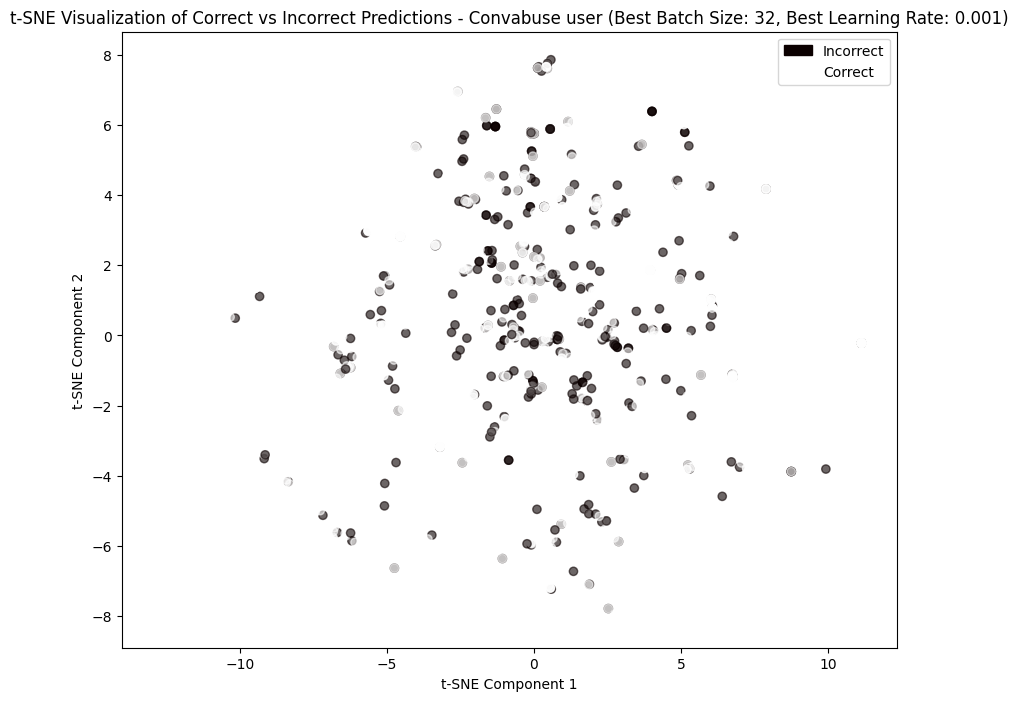

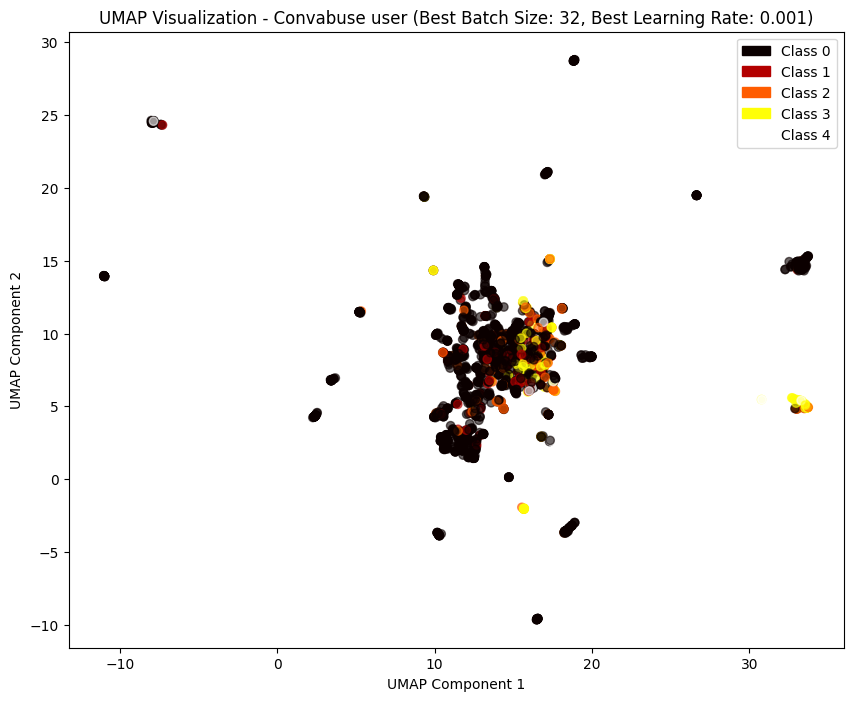

In [25]:
convabuse_user_results_list = neural_network_modeling(convabuse_user_X_train, convabuse_user_X_test, convabuse_user_y_train, convabuse_user_y_test, "Convabuse user")


Neural Network Modeling - Dataset: Dynamically Generated Hate Speech target

Training with batch size: 8, learning rate: 0.01
Epoch 1/200
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.7551 - loss: 0.6065 - val_accuracy: 0.7490 - val_loss: 0.5552 - learning_rate: 0.0100
Epoch 2/200
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7542 - loss: 0.5559 - val_accuracy: 0.7490 - val_loss: 0.5513 - learning_rate: 0.0100
Epoch 3/200
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7579 - loss: 0.5510 - val_accuracy: 0.7490 - val_loss: 0.5474 - learning_rate: 0.0100
Epoch 4/200
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7572 - loss: 0.5503 - val_accuracy: 0.7490 - val_loss: 0.5475 - learning_rate: 0.0100
Epoch 5/200
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7566 - loss: 0.5538 - val_accuracy: 0.7490 - val_loss: 0.5477 - learning_rate: 0.0100
Epoch 6/200
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7563 - loss: 0.5523 - val_ac

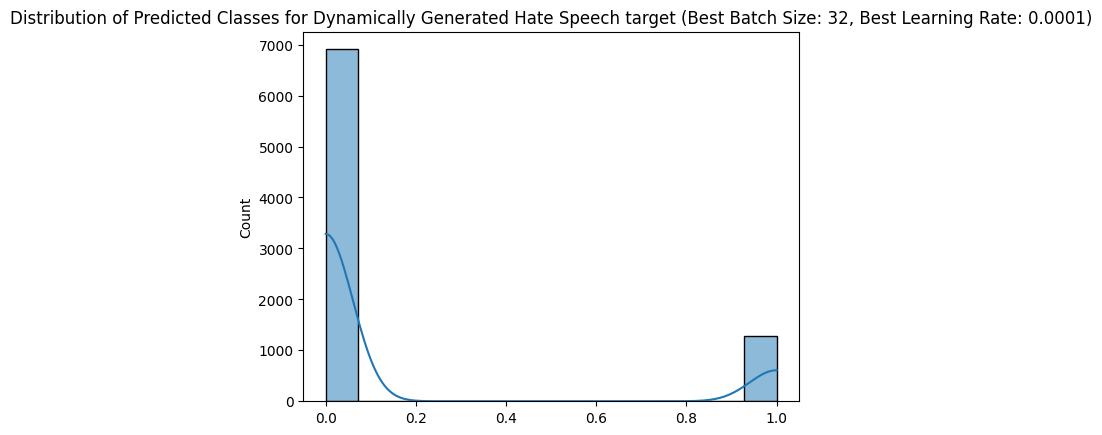

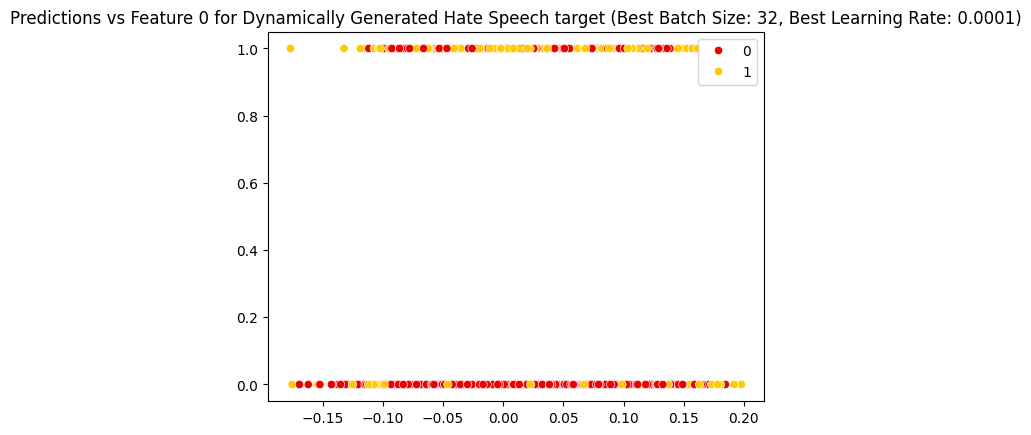

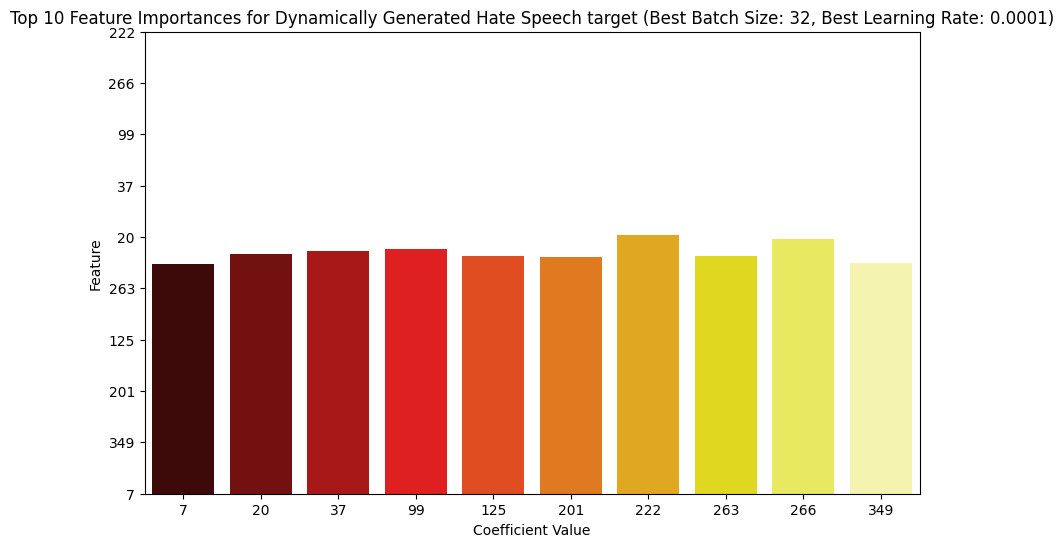

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      6190
           1       0.58      0.37      0.45      1998

    accuracy                           0.78      8188
   macro avg       0.70      0.64      0.66      8188
weighted avg       0.76      0.78      0.76      8188



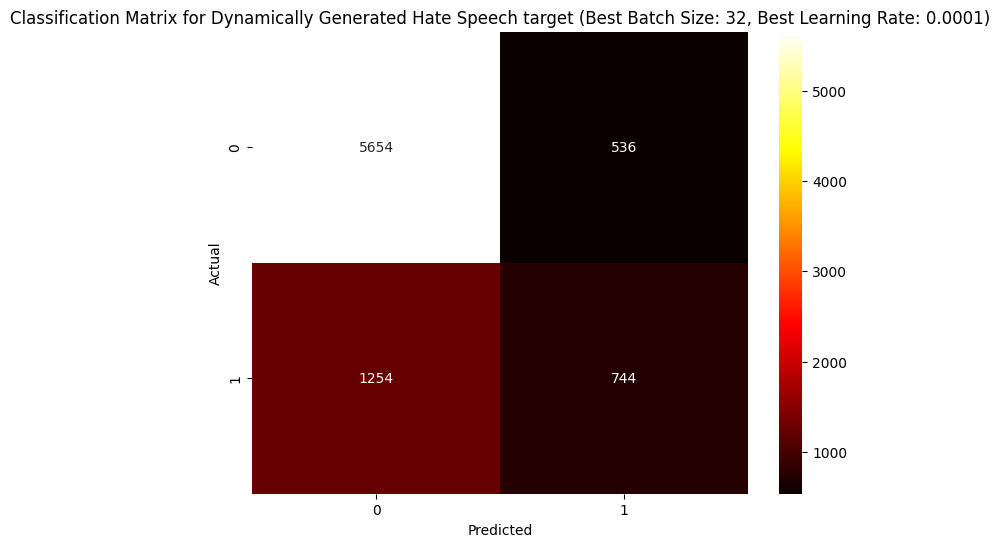

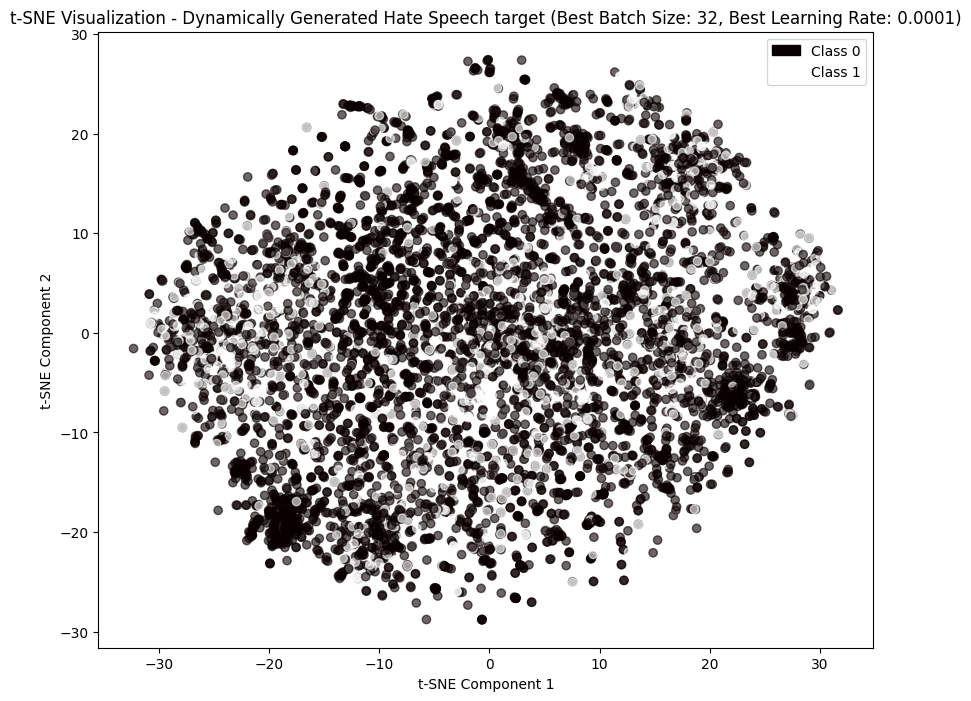

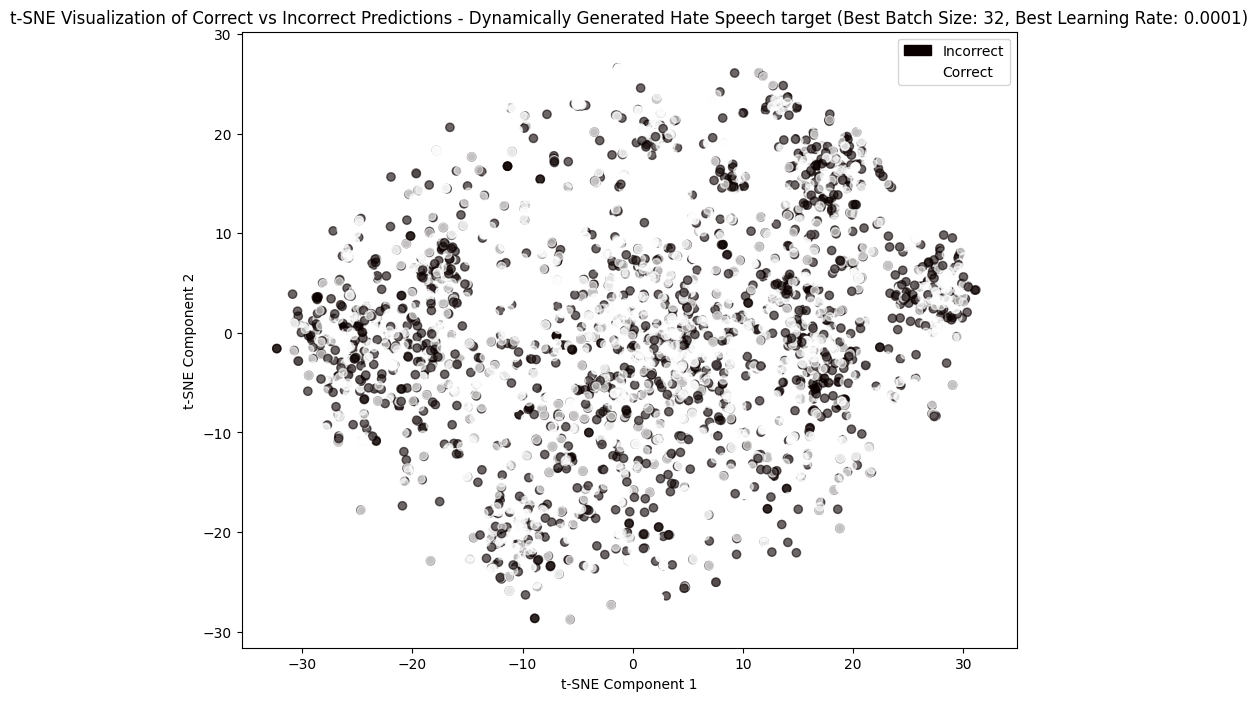

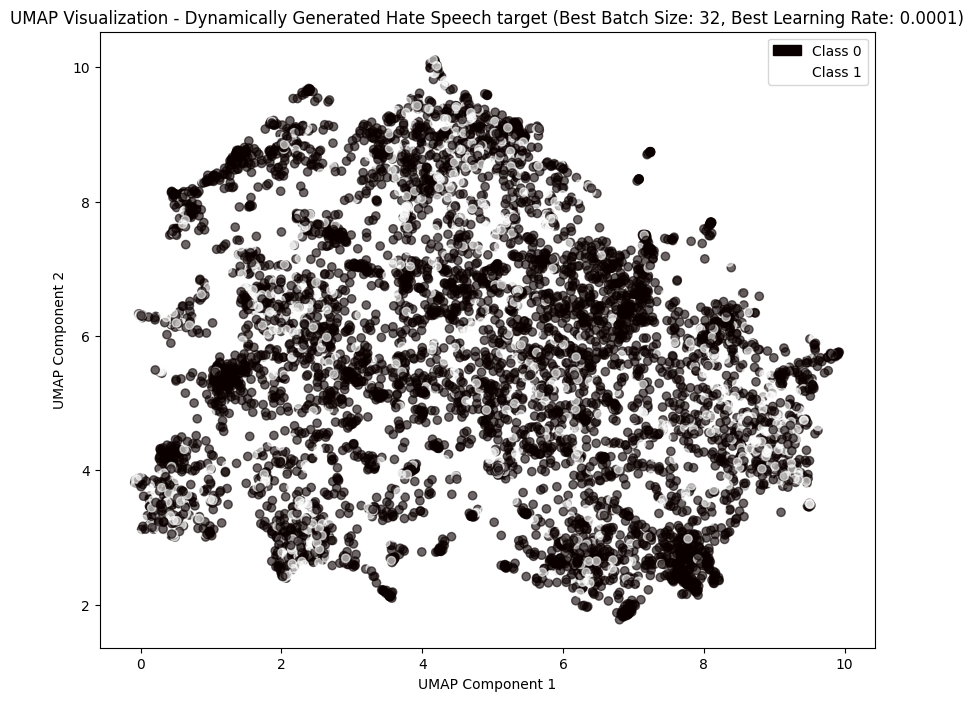

In [26]:
dghs_target_results_list = neural_network_modeling(dynamically_generated_hate_speech_target_X_train, dynamically_generated_hate_speech_target_X_test, dynamically_generated_hate_speech_target_y_train, dynamically_generated_hate_speech_target_y_test, "Dynamically Generated Hate Speech target")


Neural Network Modeling - Dataset: Dynamically Generated Hate Speech label

Training with batch size: 8, learning rate: 0.01
Epoch 1/200
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.6410 - loss: 0.7198 - val_accuracy: 0.6834 - val_loss: 0.6321 - learning_rate: 0.0100
Epoch 2/200
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6505 - loss: 0.6634 - val_accuracy: 0.6569 - val_loss: 0.6524 - learning_rate: 0.0100
Epoch 3/200
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6506 - loss: 0.6555 - val_accuracy: 0.6660 - val_loss: 0.6425 - learning_rate: 0.0100
Epoch 4/200
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6573 - loss: 0.6507 - val_accuracy: 0.6747 - val_loss: 0.6400 - learning_rate: 0.0100
Epoch 5/200
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6499 - loss: 0.6557 - val_accuracy: 0.6408 - val_loss: 0.6587 - learning_rate: 0.0100
Epoch 6/200
3266/3275 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6527 - loss: 0.6552
Epoch 6: 

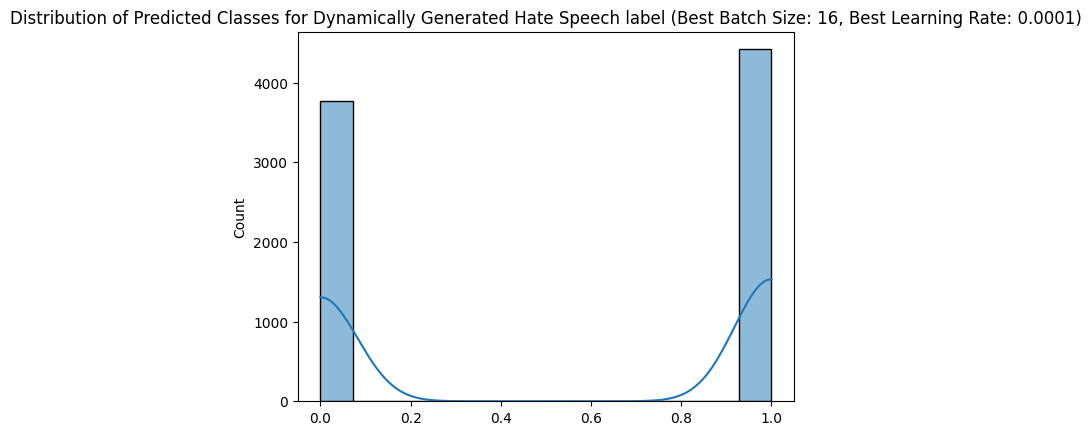

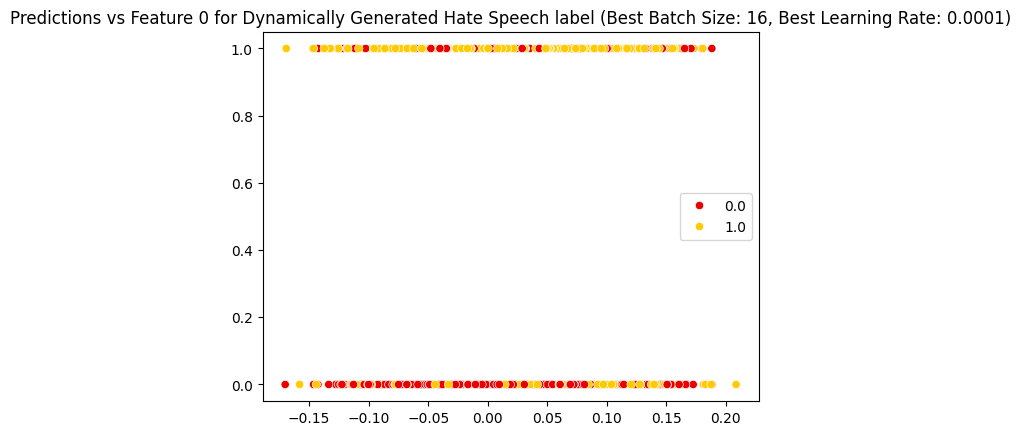

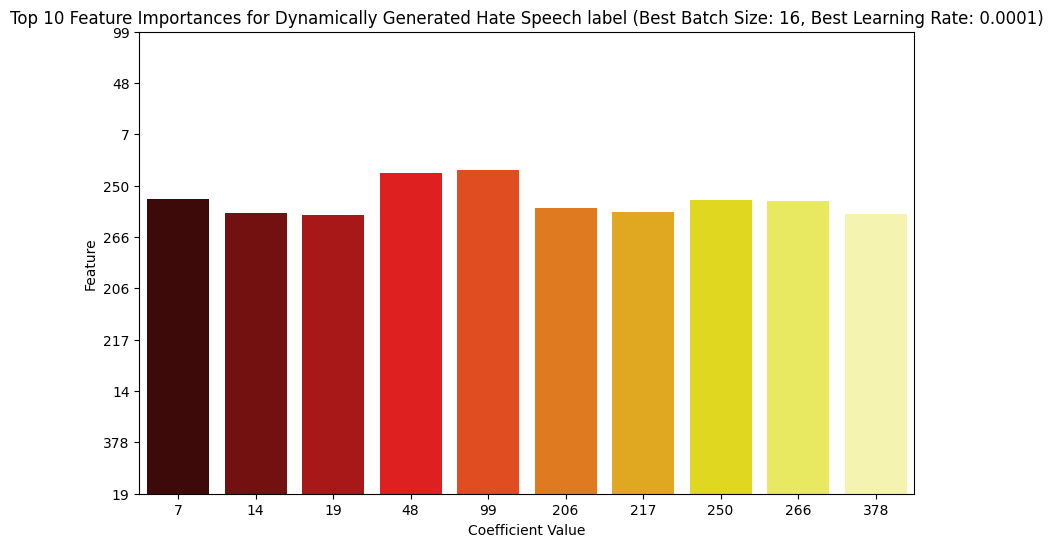

              precision    recall  f1-score   support

         0.0       0.71      0.71      0.71      3794
         1.0       0.75      0.75      0.75      4394

    accuracy                           0.73      8188
   macro avg       0.73      0.73      0.73      8188
weighted avg       0.73      0.73      0.73      8188



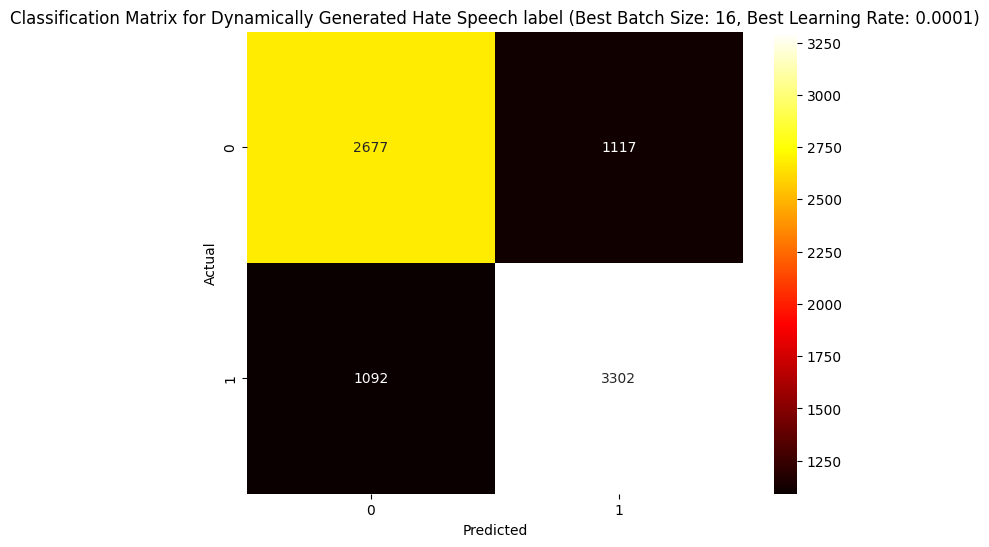

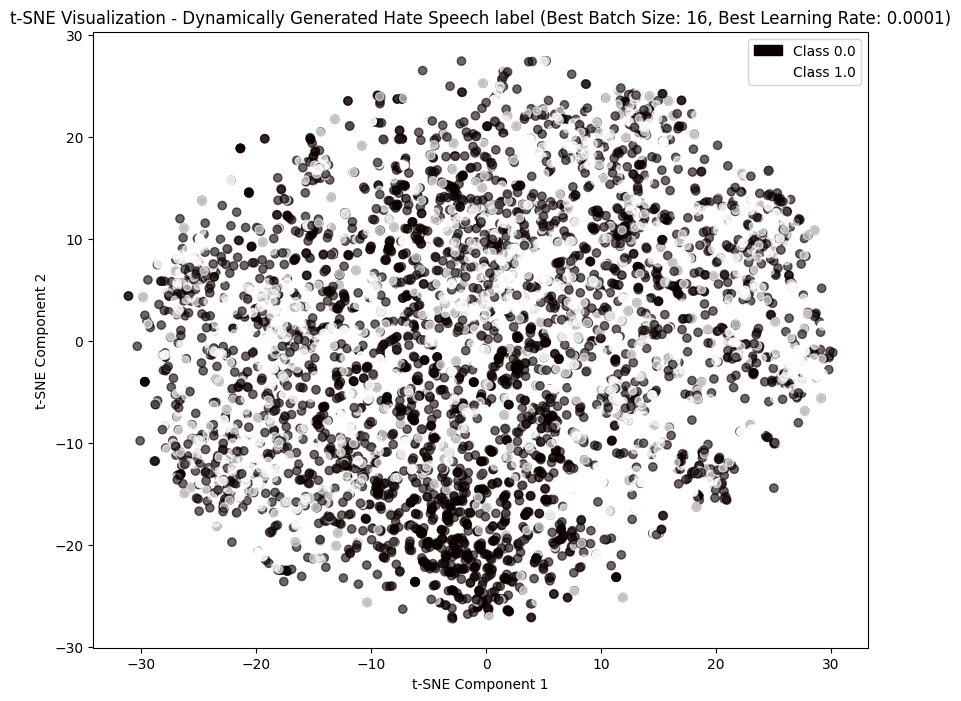

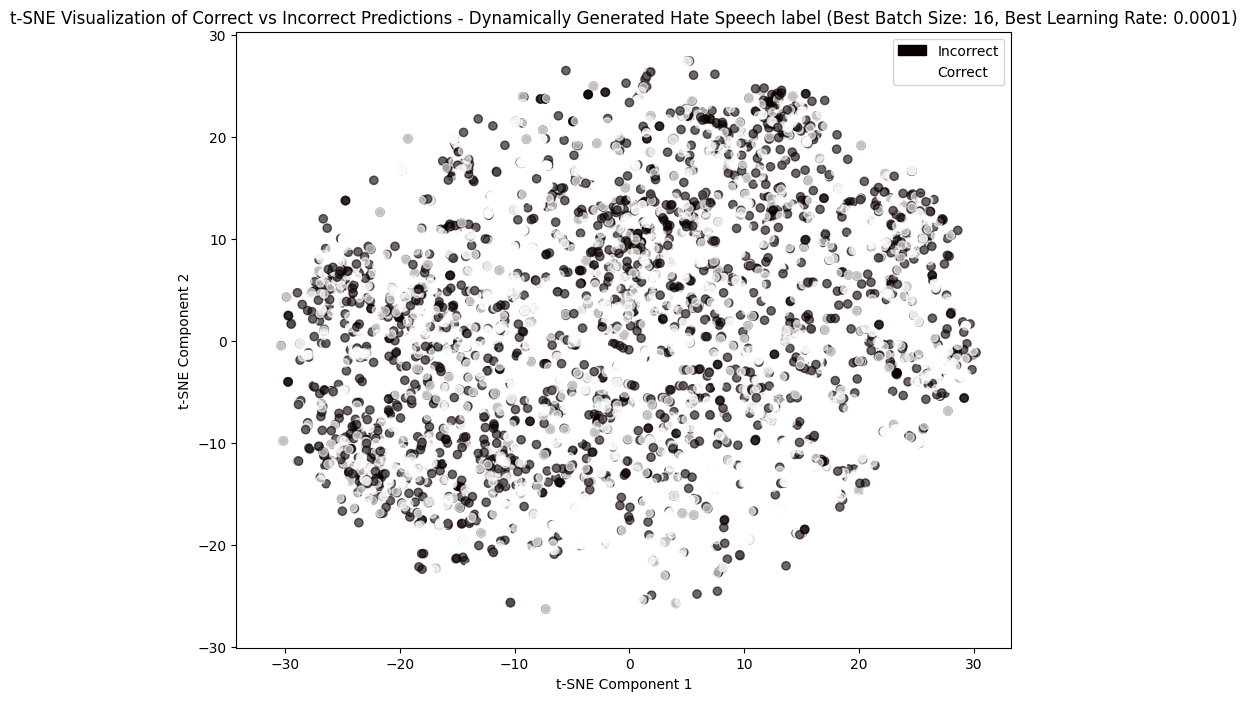

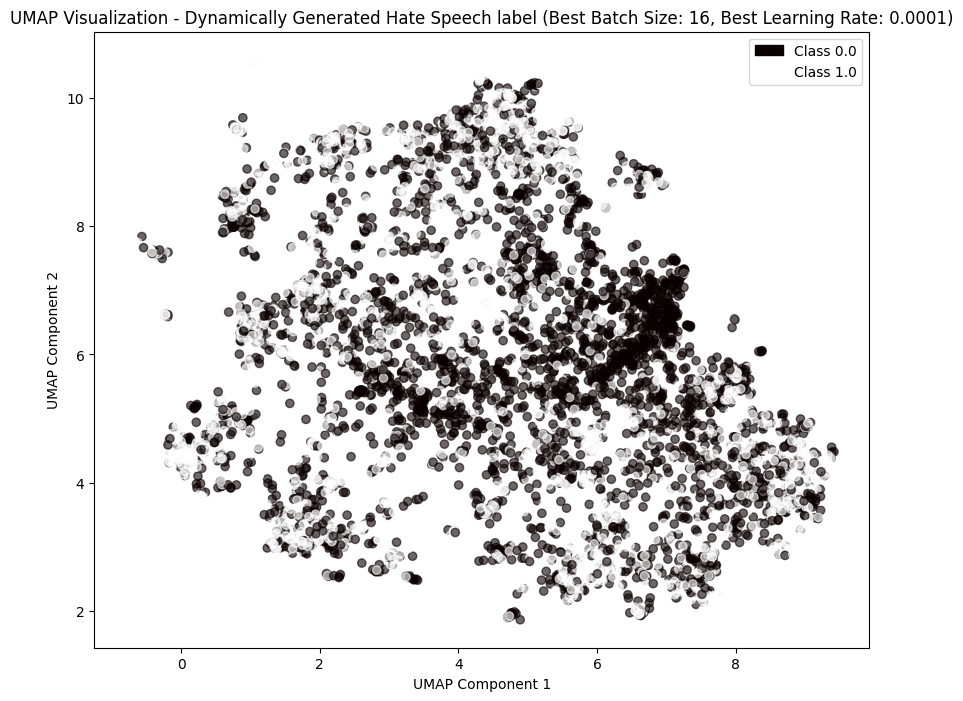

In [27]:
dghs_label_results_list = neural_network_modeling(dynamically_generated_hate_speech_label_X_train, dynamically_generated_hate_speech_label_X_test, dynamically_generated_hate_speech_label_y_train, dynamically_generated_hate_speech_label_y_test, "Dynamically Generated Hate Speech label")


Neural Network Modeling - Dataset: MLMA Hate Speech target

Training with batch size: 8, learning rate: 0.01
Epoch 1/200
904/904 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6724 - loss: 1.0305 - val_accuracy: 0.6752 - val_loss: 0.8935 - learning_rate: 0.0100
Epoch 2/200
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6841 - loss: 0.8834 - val_accuracy: 0.6752 - val_loss: 0.9005 - learning_rate: 0.0100
Epoch 3/200
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6768 - loss: 0.8953 - val_accuracy: 0.6752 - val_loss: 0.8777 - learning_rate: 0.0100
Epoch 4/200
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6763 - loss: 0.8933 - val_accuracy: 0.6752 - val_loss: 0.8845 - learning_rate: 0.0100
Epoch 5/200
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6815 - loss: 0.8834 - val_accuracy: 0.6752 - val_loss: 0.8772 - learning_rate: 0.0100
Epoch 6/200
904/904 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6780 - loss: 0.8945 - val_accuracy: 0.6752 - val_loss: 0.

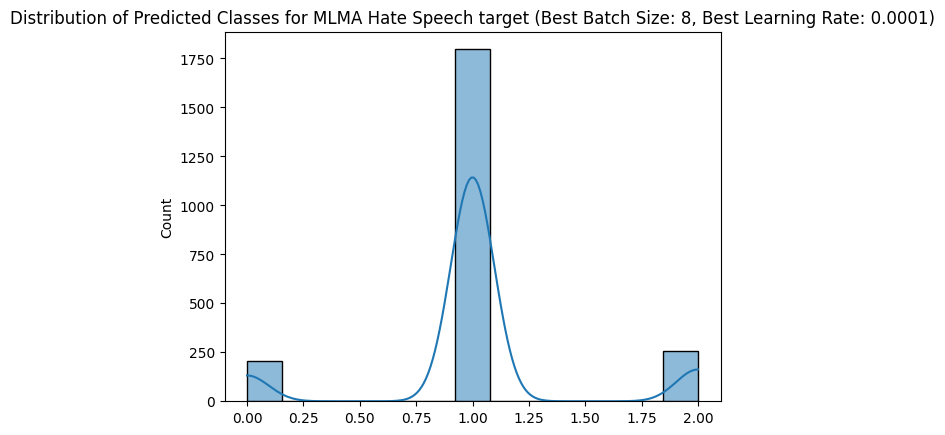

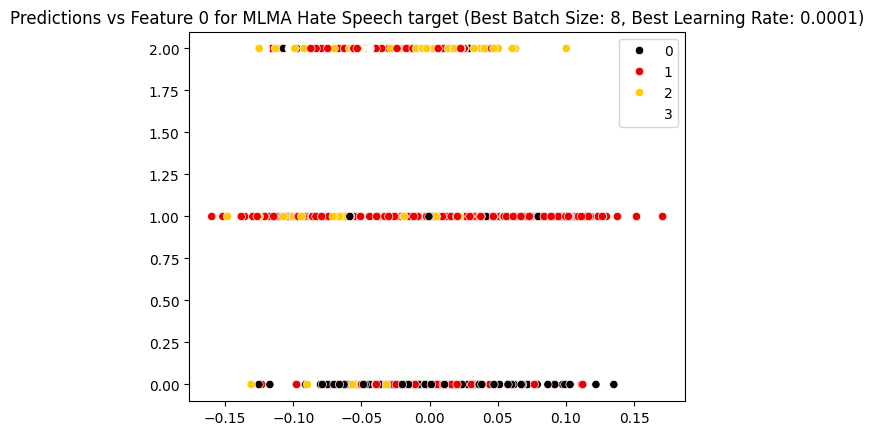

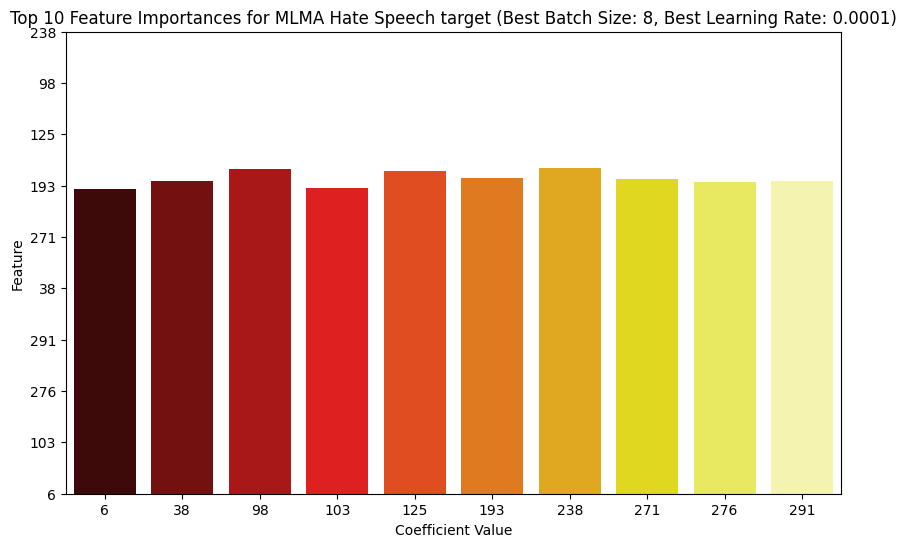

              precision    recall  f1-score   support

           0       0.63      0.51      0.56       256
           1       0.77      0.91      0.84      1529
           2       0.55      0.32      0.40       441
           3       0.00      0.00      0.00        33

    accuracy                           0.74      2259
   macro avg       0.49      0.43      0.45      2259
weighted avg       0.70      0.74      0.71      2259



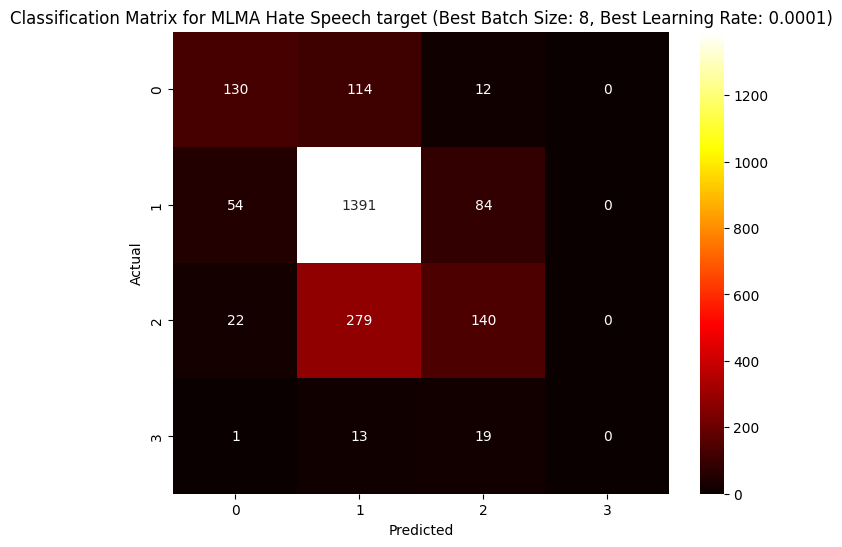

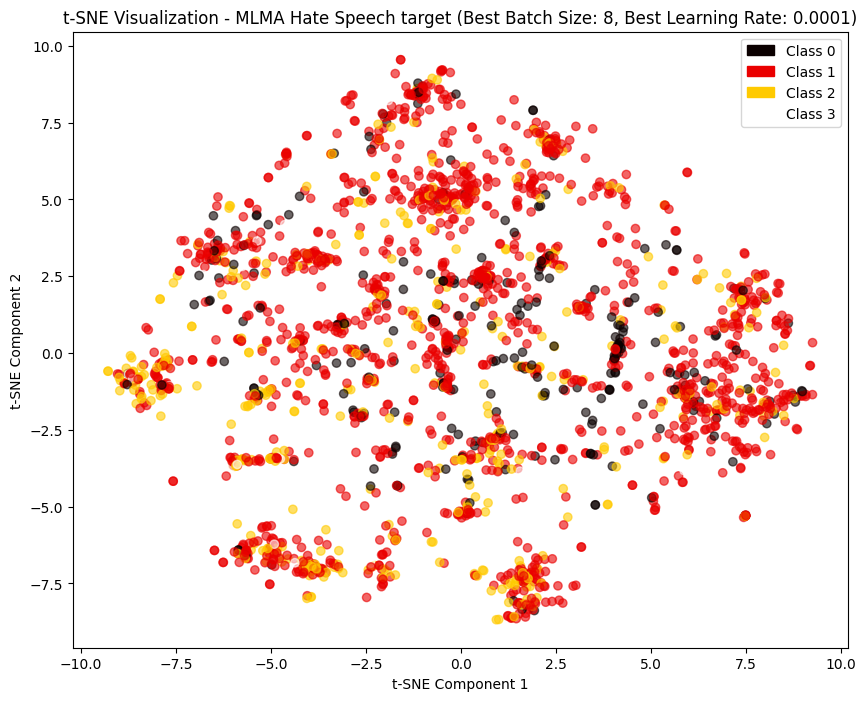

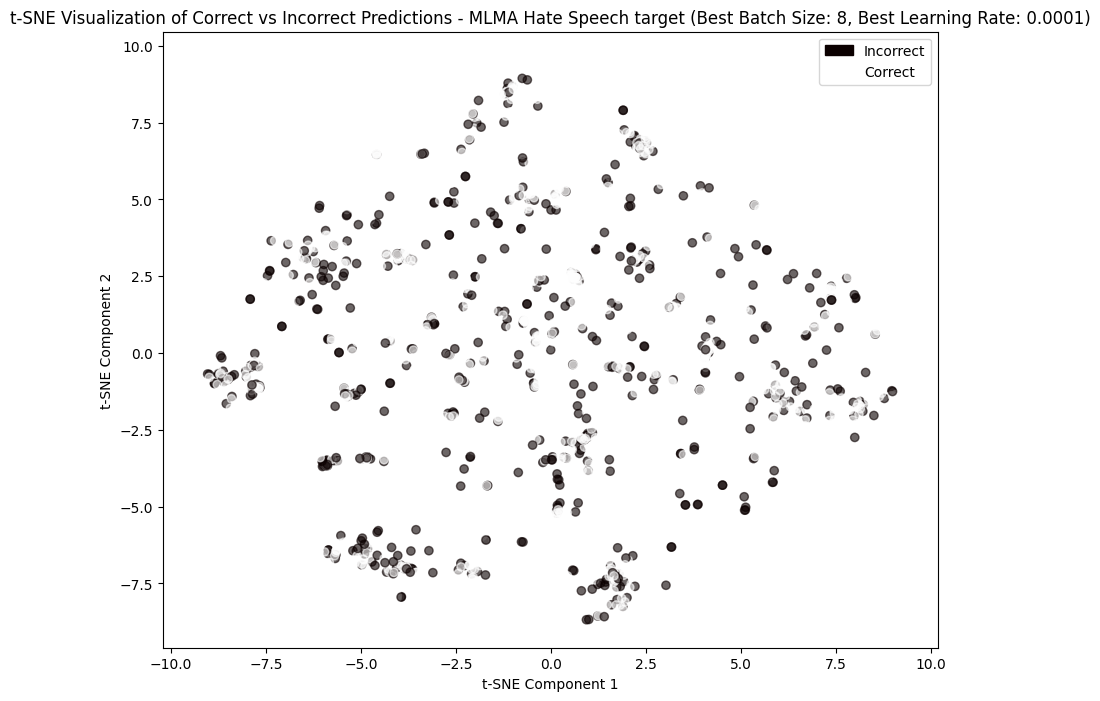

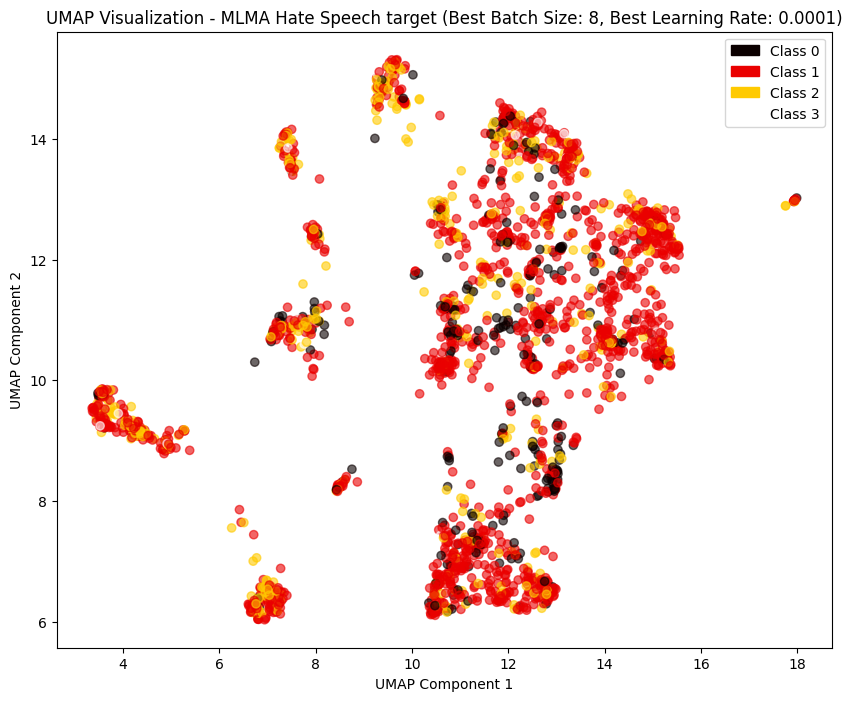

In [28]:
mlma_hate_speech_target_results_list = neural_network_modeling(mlma_hate_speech_target_X_train, mlma_hate_speech_target_X_test, mlma_hate_speech_target_y_train, mlma_hate_speech_target_y_test, "MLMA Hate Speech target")

## Logistic Regression Conclusions

In [29]:
neural_network_TSNE

{'Convabuse combined': array([[  5.2228966,   2.744265 ],
        [ -3.5852678,   1.3010175],
        [ -4.4369955,  -3.5427227],
        ...,
        [ -6.113558 ,   1.9949399],
        [ -4.5148206,   5.7522492],
        [-10.353338 ,   1.1684629]], dtype=float32),
 'Convabuse prev_agent': array([[ 3.0362554 ,  6.520925  ],
        [-4.7124276 ,  8.408251  ],
        [-6.378879  ,  7.7842016 ],
        ...,
        [ 0.02459897,  3.027028  ],
        [-4.400626  , -5.5478663 ],
        [-9.4128685 , -0.6768075 ]], dtype=float32),
 'Convabuse prev_user': array([[ 1.0587887,  4.9821877],
        [-5.1221485,  2.4836369],
        [-6.92999  ,  5.567393 ],
        ...,
        [-0.1661317, -5.9078817],
        [ 4.051224 ,  2.8636065],
        [ 6.0735655, -2.6643279]], dtype=float32),
 'Convabuse agent': array([[ 3.7054372 , -4.493099  ],
        [-2.4682417 , -8.925916  ],
        [ 0.10219776,  9.848582  ],
        ...,
        [-8.635005  ,  0.3843995 ],
        [-6.938796  , -2.3484

In [30]:
neural_network_UMAP

{'Convabuse combined': array([[ 0.7504986 , -2.2472036 ],
        [ 2.3210032 ,  3.5606773 ],
        [-0.24687068, 10.761439  ],
        ...,
        [13.548481  ,  3.889622  ],
        [12.882447  ,  2.5005748 ],
        [17.491783  , -2.912161  ]], dtype=float32),
 'Convabuse prev_agent': array([[-16.602242 ,  11.268116 ],
        [ -5.255605 , -13.371522 ],
        [ -7.929334 ,  -1.7718071],
        ...,
        [  4.147248 ,  -2.4935176],
        [ 21.19829  ,  14.257693 ],
        [ 24.517155 ,  -6.5677805]], dtype=float32),
 'Convabuse prev_user': array([[13.751587 , 10.297446 ],
        [26.17423  ,  1.5985209],
        [26.216488 ,  1.4993128],
        ...,
        [14.009737 ,  7.9558444],
        [11.886861 ,  6.44521  ],
        [ 5.1490555, 21.611387 ]], dtype=float32),
 'Convabuse agent': array([[ 14.055573 ,  21.912868 ],
        [-13.565541 ,  17.24999  ],
        [  8.490866 , -15.566611 ],
        ...,
        [  7.342302 ,  -5.1774235],
        [ 12.244935 ,  -5.004

In [31]:
# Pickle both dictionaries
with open(f'{pickle_path}neural-network-TSNE-dict-original-imbalanced.pkl', 'wb') as f:
    pickle.dump(neural_network_TSNE, f)
with open(f'{pickle_path}neural-network-UMAP-dict-original-imbalanced.pkl', 'wb') as f:
    pickle.dump(neural_network_UMAP, f)

In [32]:
# Compile the results into logistic_regression_model_results
neural_network_model_results = [convabuse_combined_results_list, convabuse_prev_agent_results_list, convabuse_prev_user_results_list, convabuse_agent_results_list, convabuse_user_results_list, dghs_target_results_list, dghs_label_results_list, mlma_hate_speech_target_results_list]
neural_network_model_results = [pd.DataFrame(item) for item in neural_network_model_results]

neural_network_model_summary = pd.concat(neural_network_model_results, ignore_index=True)
neural_network_model_summary["Balance"] = "Imbalanced"

# Rename Top 10 Importances to Feature Importances
neural_network_model_summary = neural_network_model_summary.rename(columns={"Top 10 Importances": "Feature Importances"})
neural_network_model_summary

,Dataset,Model,Optimizer,Accuracy,F1-score,Macro F1-score,Ratio,Best Batch Size,Best Learning Rate,Importances,Feature Importances,Balance
0,Convabuse combined,Neural Network,Adam,0.839428,0.798344,0.334895,0,16,0.0001,"{0: 3.8368156, 1: 3.8548226, 2: 4.7216063, 3: ...","{149: 5.709761, 245: 5.7428913, 104: 5.767343,...",Imbalanced
1,Convabuse prev_agent,Neural Network,Adam,0.800079,0.711221,0.177788,0,8,0.0100,"{0: 0.04721532, 1: 0.24084145, 2: 0.023385074,...","{288: 0.41127294, 194: 0.416121, 164: 0.416950...",Imbalanced
2,Convabuse prev_user,Neural Network,Adam,0.813990,0.754209,0.264217,0,64,0.0001,"{0: 4.7617655, 1: 3.8710103, 2: 4.112814, 3: 3...","{347: 5.2178965, 231: 5.278824, 98: 5.3542767,...",Imbalanced
3,Convabuse agent,Neural Network,Adam,0.800079,0.711221,0.177788,0,8,0.0100,"{0: 0.059801813, 1: 0.30644912, 2: 0.029257469...","{259: 0.37208194, 317: 0.37668175, 225: 0.3775...",Imbalanced
4,Convabuse user,Neural Network,Adam,0.858506,0.828545,0.440576,0,32,0.0010,"{0: 2.168736, 1: 2.403336, 2: 2.0430114, 3: 1....","{251: 3.4352374, 98: 3.4611745, 349: 3.4658241...",Imbalanced
5,Dynamically Generated Hate Speech target,Neural Network,Adam,0.781387,0.763437,0.658637,0,32,0.0001,"{0: 3.5804954, 1: 3.3639555, 2: 3.2721288, 3: ...","{7: 4.476304, 349: 4.5001106, 201: 4.609803, 1...",Imbalanced
6,Dynamically Generated Hate Speech label,Neural Network,Adam,0.730215,0.730152,0.728634,0,16,0.0001,"{0: 4.6563916, 1: 4.6782074, 2: 4.084142, 3: 3...","{19: 5.4338303, 378: 5.4444213, 14: 5.4669666,...",Imbalanced
7,MLMA Hate Speech target,Neural Network,Adam,0.735281,0.708317,0.450074,0,8,0.0001,"{0: 5.583474, 1: 4.4714565, 2: 4.4721565, 3: 4...","{6: 5.9408507, 103: 5.9653053, 276: 6.076587, ...",Imbalanced


In [33]:
neural_network_model_summary.to_csv("/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/results/sentiment_analysis_model12_neural-network-summary_imbalanced.csv", index=False)